In [46]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mahmoudmansouri/datasetiot/train_test_network(in).csv
/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv


# Système de Détection d'Intrusions Réseau (NIDS) : Analyse et Modélisation

## Table des matières

**1. Introduction**
* 1.1. Introduction et Cadre du projet
* 1.2. Origine et Intégrité des données

**2. Analyse Exploratoire des Données (EDA)**
* 2.1. Analyse des vecteurs d'attaque selon les protocoles
* 2.2. Phase d'exploration : Empreintes et signatures des attaques
* 2.3. Analyse visuelle : Le chevauchement central et les limites volumétriques

**3. Pipeline de Préparation des Données**
* 3.1. Phase de prétraitement : Transformation et ingénierie des données
* 3.2. Phase de préparation : Fractionnement (Train/Test) et formatage

**4. Expérimentations Deep Learning (Évaluation des limites)**
* 4.1. Modélisation CNN 1D : Entraînement et limites spatiales
* 4.2. Pivot technologique : Transition vers un Réseau de Neurones Dense (DNN)
* 4.3. Modélisation DNN : Entraînement et diagnostic du surapprentissage
* 4.4. Architecture hybride (CNN + DNN) : Le plafond de verre du Deep Learning

**5. Modélisation Finale (Le choix de l'efficacité)**
* 5.1. L'approche ensembliste : Transition vers XGBoost
* 5.2. Phase de modélisation : Entraînement du modèle XGBoost
* 5.3. Diagnostic final (XGBoost) : Évaluation des performances et Matrice de confusion

**6. Explicabilité du Modèle (XAI) et Threat Intelligence**
* 6.1. Explicabilité globale : Analyse de l'importance des variables
* 6.2. Explicabilité locale : Analyse de la connexion n° 42 avec SHAP

---

## 1. Introduction

### 1.1. Introduction et Cadre du Projet

Ce projet s'inscrit initialement en réponse au sujet d'étude qui m'a été assigné : **"4- Conventional Neural Network to detect IoT attacks based on TON-IoT dataset (Mahmoud Mansouri)"**. 

Si j'ai rigoureusement implémenté et évalué cette architecture de réseau de neurones convolutif (CNN) tel que requis, j'ai pris l'initiative d'élargir le périmètre de cette recherche. Pour m'assurer d'obtenir les meilleurs résultats possibles et d'adopter une démarche scientifique exhaustive, j'ai choisi de concevoir et de tester d'autres architectures d'apprentissage (DNN, modèle hybride, puis XGBoost). L'objectif est de confronter empiriquement les performances du CNN à d'autres paradigmes pour identifier le modèle le plus adapté à ces données, comprendre ses limites mathématiques, et aboutir à une conclusion technique définitive.

### 1.2. Origine et Intégrité des Données

L'intégrité et la fiabilité des données sont des prérequis non négociables. L'intégralité du jeu de données TON-IoT utilisé pour entraîner et évaluer ces modèles d'intelligence artificielle a donc été téléchargée directement depuis les sources officielles. 

Cette démarche stricte me garantit que les signatures d'attaques, tout comme le trafic légitime analysés dans les sections suivantes, sont authentiques, non altérées et rigoureusement représentatives des menaces rencontrées dans des environnements réseaux réels.

In [47]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Conv1D, MaxPooling1D, Flatten, 
    Dropout, BatchNormalization, Activation, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

## 2. Analyse Exploratoire des Données (EDA)

### Phase 0 : Chargement et évaluation initiale

Avant toute manipulation, il est indispensable d'évaluer la structure des données brutes. Je charge ici le jeu de données du trafic réseau et procède à la suppression immédiate des doublons afin de garantir l'intégrité de l'analyse. 

J'effectue ensuite une première évaluation exploratoire pour inspecter les éléments suivants :

1. **Types de données et volumétrie :** Évaluer la taille du jeu de données et identifier les types de variables (numériques vs catégorielles) à traiter.
2. **Résumé statistique :** Observer la distribution de base, les moyennes et identifier les valeurs aberrantes (outliers) extrêmes au sein des caractéristiques réseau.
3. **Valeurs manquantes :** Confirmer la propreté structurelle du dataset. 
4. **Distributions des classes (Cibles) :** Inspecter les variables cibles binaire (`label`) et multiclasse (`type`) pour quantifier les déséquilibres (ex. : le volume de trafic normal face aux attaques spécifiques comme DDoS ou MITM). Cette observation conditionnera ma stratégie d'équilibrage lors du prétraitement.

In [48]:
df = pd.read_csv('/kaggle/input/datasets/mahmoudmansouri/datasetiot/train_test_network(in).csv')

df = df.drop_duplicates()

print("--- Types de données et utilisation de la mémoire ---")
df.info()

print("\n--- Résumé statistique des colonnes numériques ---")
display(df.describe())

print("\n--- Vérification des valeurs manquantes ---")
missing_vals = df.isnull().sum()
display(missing_vals[missing_vals > 0])

print("\n--- Distribution des types d'attaques (Multiclasse) ---")
display(df['type'].value_counts())

print("\n--- Distribution des étiquettes binaires (0: Normal, 1: Attaque) ---")
display(df['label'].value_counts())

--- Types de données et utilisation de la mémoire ---
<class 'pandas.core.frame.DataFrame'>
Index: 190474 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  190474 non-null  object 
 1   src_port                190474 non-null  int64  
 2   dst_ip                  190474 non-null  object 
 3   dst_port                190474 non-null  int64  
 4   proto                   190474 non-null  object 
 5   service                 190474 non-null  object 
 6   duration                190474 non-null  float64
 7   src_bytes               190474 non-null  int64  
 8   dst_bytes               190474 non-null  int64  
 9   conn_state              190474 non-null  object 
 10  missed_bytes            190474 non-null  int64  
 11  src_pkts                190474 non-null  int64  
 12  src_ip_bytes            190474 non-null  int64  
 13  dst_pkts                1

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,190474.000000,190474.000000,190474.000000,1.904740e+05,1.904740e+05,1.904740e+05,190474.000000,1.904740e+05,190474.000000,1.904740e+05,190474.000000,190474.000000,190474.000000,190474.000000,1.904740e+05,190474.000000,190474.000000
mean,39755.028098,2136.147989,8.532477,2.859868e+05,2.867525e+05,3.815064e+04,10.559882,8.480142e+02,4.248890,1.755264e+03,251.518585,3.923071,0.137378,0.072482,1.605803e+02,0.336723,0.779287
std,18808.989174,6971.550976,593.815814,1.799405e+07,1.897376e+07,5.538425e+06,96.557801,2.346881e+04,348.102025,2.001842e+05,2858.889139,24.959591,0.628847,9.729679,3.207557e+04,8.704852,0.414728
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,35650.000000,53.000000,0.000009,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,45729.500000,80.000000,0.000391,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.040000e+02,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,52042.750000,445.000000,0.136369,1.300000e+02,1.780000e+02,0.000000e+00,5.000000,4.230000e+02,2.000000,2.340000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000



--- Vérification des valeurs manquantes ---


Series([], dtype: int64)


--- Distribution des types d'attaques (Multiclasse) ---


type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64


--- Distribution des étiquettes binaires (0: Normal, 1: Attaque) ---


label
1    148434
0     42040
Name: count, dtype: int64

### Interprétation de l'Exploration des Données (EDA)

Cette analyse initiale de mon jeu de données met en évidence plusieurs contraintes techniques qui dictent ma stratégie de modélisation :

1. **Structure et intégrité :**
   * Mon dataset se compose de **190 474 paquets réseau** et **44 caractéristiques**.
   * L'absence de valeurs manquantes me permet de passer directement à la phase de traitement sans étape d'imputation.
   * La consommation mémoire (~65 Mo) autorise un traitement fluide en mémoire vive.

2. **Dynamique des variables (Valeurs aberrantes) :**
   * J'observe une asymétrie extrême dans les données réseau. La médiane des octets sources (`src_bytes`) est nulle alors que les maxima sont massifs. De même, la durée (`duration`) est majoritairement inférieure à une seconde mais présente des pics isolés à 93 000 secondes.
   * **Décision technique :** Ces écarts types élevés m'imposent d'appliquer une mise à l'échelle rigoureuse (via `StandardScaler`) pour garantir la stabilité de l'apprentissage de mes futurs modèles.

3. **Déséquilibre des classes :**
   * Le dataset présente une asymétrie inverse par rapport à un trafic réel : il contient **78 % d'attaques (148 434)** contre **22 % de trafic normal (42 040)**.
   * Si la répartition multiclasse est globalement homogène pour les menaces majeures, les attaques **MITM (Man-In-The-Middle)** sont sous-représentées avec seulement 1 041 échantillons.
   * **Conséquence :** L'algorithme disposera d'une base d'apprentissage restreinte pour le MITM face à la masse de données DDoS. Ce constat justifie d'ores et déjà mon intention d'explorer des algorithmes robustes face au déséquilibre, tels que XGBoost.

### 2.1. Analyse des vecteurs d'attaque selon les protocoles

Les cyberattaques exploitent systématiquement les spécificités de certains protocoles. Par exemple, les dénis de service (DDoS) s'appuient massivement sur des protocoles sans connexion comme UDP, tandis que les injections ou XSS ciblent la couche applicative via HTTP. Je génère ici un graphique à barres pour analyser cette répartition :

1. **Filtrage (Top 15) :** Un réseau réel utilisant des centaines de protocoles mineurs, j'isole uniquement les 15 protocoles générant le plus de trafic afin de garder mon analyse pertinente et lisible.
2. **Échelle logarithmique (`yscale('log')`) :** Le volume de trafic étant fortement asymétrique (les protocoles majeurs transportent des millions de paquets contre quelques milliers pour d'autres), j'applique une échelle logarithmique sur l'axe Y. Cela me permet de comparer tous les protocoles de manière équitable, sans que les plus volumineux n'écrasent visuellement les autres.
3. **Interprétation :** Ce visuel m'aide à identifier immédiatement quels protocoles sont "sains" (majorité de trafic normal) et lesquels servent de vecteurs malveillants (majorité d'attaques). Cette observation confirme d'ores et déjà que la caractéristique du protocole (`proto`) sera un indicateur prédictif déterminant pour l'entraînement de mon modèle.

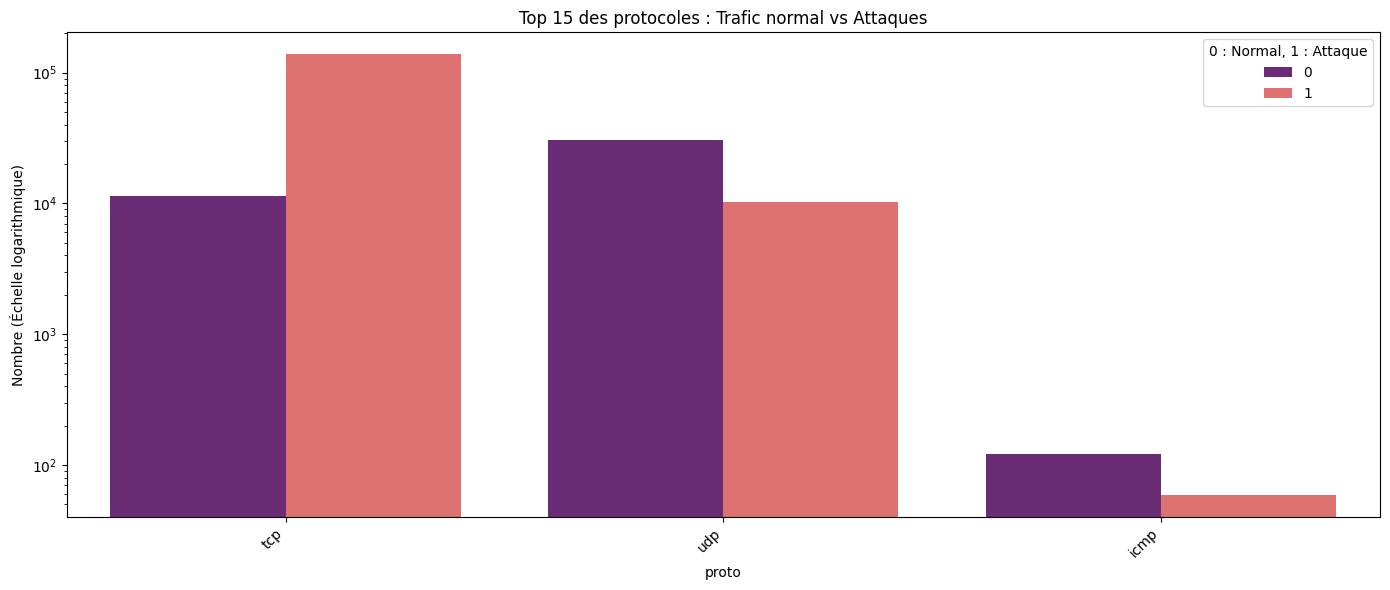

In [53]:
plt.figure(figsize=(14, 6))

top_protos = df['proto'].value_counts().nlargest(15).index
filtered_df = df[df['proto'].isin(top_protos)]

sns.countplot(data=filtered_df, x='proto', hue='label', palette='magma')
plt.title('Top 15 des protocoles : Trafic normal vs Attaques')
plt.yscale('log')
plt.ylabel('Nombre (Échelle logarithmique)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='0 : Normal, 1 : Attaque')

plt.tight_layout()
plt.show()

### Analyse des vecteurs d'attaque (Résultats)

Ce graphique à barres en échelle logarithmique illustre la répartition du trafic selon les protocoles réseau. Trois protocoles majeurs (`tcp`, `udp` et `icmp`) se détachent et mettent en évidence une dynamique de compromission claire :

1. **La domination de TCP comme vecteur d'attaque :**
   J'observe une forte disproportion sur le protocole **TCP**. Le volume d'attaques dépasse les 100 000 requêtes ($10^5$), écrasant complètement le trafic normal. Dans mon jeu de données, la très grande majorité des attaques (injections, attaques sur mots de passe, ransomwares, ou DoS) exploitent TCP pour établir leurs canaux malveillants.

2. **UDP, un protocole majoritairement légitime :**
   La tendance s'inverse pour **UDP**. Le trafic normal (environ 30 000 paquets) y est nettement supérieur au trafic malveillant (environ 10 000 paquets). Bien qu'UDP soit couramment utilisé pour des attaques DDoS en conditions réelles, il reste majoritairement sain dans cet environnement spécifique.

3. **ICMP, un volume global faible :**
   Ce protocole, utilisé pour le diagnostic, génère un volume de trafic très marginal par rapport aux deux autres, avec une légère prédominance de trafic légitime.

**Conclusion pour la modélisation :**
Ce graphique me confirme que la variable catégorielle `proto` est une **caractéristique hautement discriminante**. Mes futurs modèles d'apprentissage exploiteront rapidement cette règle statistique évidente : si une connexion utilise TCP, la probabilité qu'il s'agisse d'une attaque est drastiquement plus élevée. C'est l'identification de ces signaux forts qui me permettra d'isoler efficacement les menaces par la suite.

### 2.2. Phase d'exploration : Empreintes et signatures des attaques

#### Comportement des variables asymétriques (Échelle logarithmique)

Les données de trafic réseau étant fortement asymétriques, un graphique classique serait illisible et écrasé par les valeurs extrêmes. En effet, la majorité des paquets transfèrent peu de données en une fraction de seconde, tandis que certaines attaques génèrent des volumes massifs.

Pour contourner ce problème, j'applique une transformation logarithmique (`np.log1p`) associée à des boîtes à moustaches (boxplots). Cela me permet de "compresser" visuellement l'échelle et de comparer correctement le cœur des distributions :

1. **Volume d'octets sources (`src_bytes`) :** J'analyse le volume de données pour vérifier si certains types d'attaques se démarquent par des charges utiles anormalement lourdes ou, au contraire, par des paquets artificiellement légers.
2. **Durée de la connexion (`duration`) :** J'étudie la dimension temporelle du trafic. Cela me permet d'observer, par exemple, si les attaques par balayage (scans) présentent des durées quasi nulles, ou si les attaques furtives tentent de maintenir des sessions ouvertes sur de longues périodes.
3. **Nettoyage post-analyse :** Je supprime ces colonnes logarithmiques temporaires à la fin de cette cellule pour garder mon dataset intact. La mise à l'échelle définitive des variables sera rigoureusement gérée par mon `StandardScaler` lors de la phase de prétraitement.

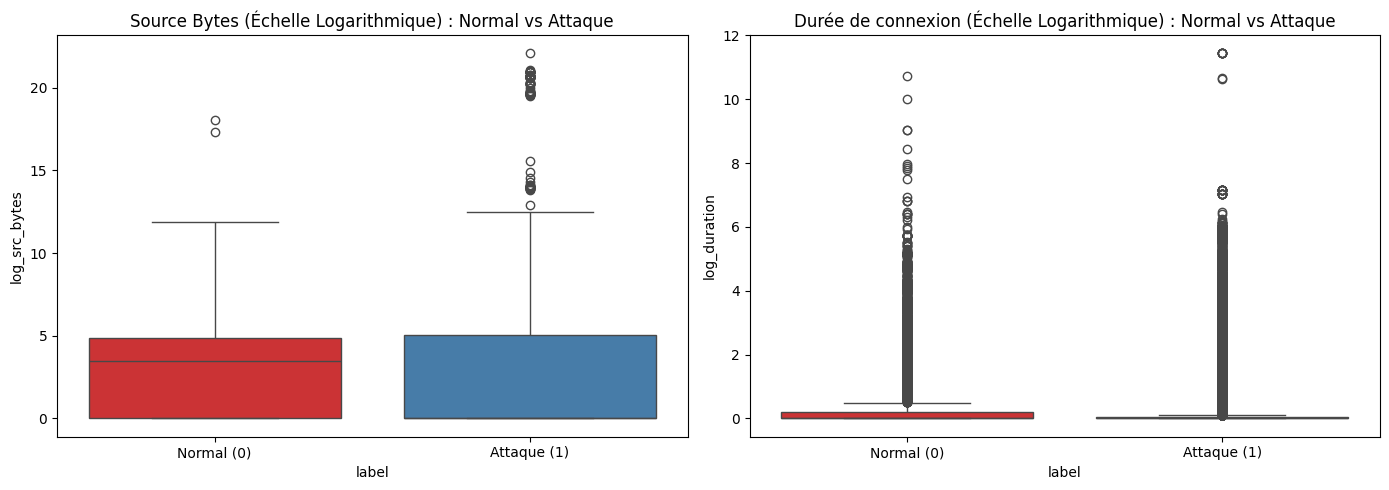

In [52]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df['log_src_bytes'] = np.log1p(df['src_bytes'])
sns.boxplot(x='label', y='log_src_bytes', hue='label', data=df, palette='Set1', legend=False)
plt.title('Source Bytes (Échelle Logarithmique) : Normal vs Attaque')
plt.xticks([0, 1], ['Normal (0)', 'Attaque (1)'])

plt.subplot(1, 2, 2)
df['log_duration'] = np.log1p(df['duration'])
sns.boxplot(x='label', y='log_duration', hue='label', data=df, palette='Set1', legend=False)
plt.title('Durée de connexion (Échelle Logarithmique) : Normal vs Attaque')
plt.xticks([0, 1], ['Normal (0)', 'Attaque (1)'])

plt.tight_layout()
plt.show()

df = df.drop(columns=['log_src_bytes', 'log_duration'])

### Analyse des distributions visuelles (Résultats)

L'analyse de ces boxplots en échelle logarithmique met en évidence des différences de comportement nettes entre le trafic légitime et malveillant. Cela valide la pertinence de ces variables pour mon modèle :

1. **Source Bytes :**
   * Le trafic normal (0) présente une distribution concentrée autour d'une médiane basse.
   * Le trafic d'attaque (1) montre une **variance beaucoup plus importante vers le haut**. La présence d'une ligne très dense de valeurs aberrantes (outliers) aux niveaux maximums m'indique que de nombreuses attaques (comme les DDoS volumétriques ou l'exfiltration de données) s'appuient sur l'injection de charges utiles massives.

2. **Durée de la connexion (Connection Duration) :**
   * La distribution des attaques (1) est écrasée vers zéro, mais elle est surmontée d'une très forte concentration de valeurs extrêmes supérieures. 
   * **Interprétation comportementale :** J'identifie des profils temporels d'attaques extrêmes. D'une part, des attaques ultra-courtes (fraction de milliseconde), caractéristiques des scans ou des dénis de service. D'autre part, des connexions anormalement longues, typiques des attaques furtives (comme les backdoors) qui maintiennent des sessions ouvertes en attente d'instructions.

#### Nuage de points : Signatures volumétriques multiclasses

Chaque type d'attaque réseau possède une signature comportementale qui lui est propre. Par exemple, une attaque volumétrique de type DDoS présente un profil de transfert de données radicalement différent d'une attaque furtive par force brute. 

Ce bloc de code génère un nuage de points (scatter plot) pour visualiser ces signatures, en croisant le nombre de paquets envoyés avec le volume d'octets transférés :

1. **Filtrage (Top 5) :** Afin de garantir la lisibilité du graphique, j'isole exclusivement le trafic malveillant (`label == 1`) et je ne conserve que les 5 types d'attaques les plus fréquents. Sans ce filtre, le chevauchement des points rendrait l'analyse visuelle impossible.
2. **Échelle logarithmique bivariée :** J'applique une transformation logarithmique (`np.log1p`) sur les deux axes (Octets et Paquets). Cela me permet de regrouper visuellement les flux extrêmes et de faire ressortir d'éventuels clusters.
3. **Interprétation visuelle (Clustering naturel) :** * L'objectif est d'observer si les attaques (différenciées par couleur) forment des groupes isolés ou si elles se superposent.
   * **Si des clusters distincts apparaissent :** Cela m'indique que le volume de données (octets/paquets) suffira pour différencier ces attaques.
   * **En cas de fort chevauchement :** Cela confirmera que mon futur modèle d'apprentissage ne pourra pas se fier uniquement aux volumes pour la classification multiclasse (`type`). Il devra impérativement s'appuyer sur des combinaisons plus complexes intégrant d'autres variables (comme le protocole, les indicateurs HTTP ou l'état de la connexion) pour distinguer précisément chaque menace.

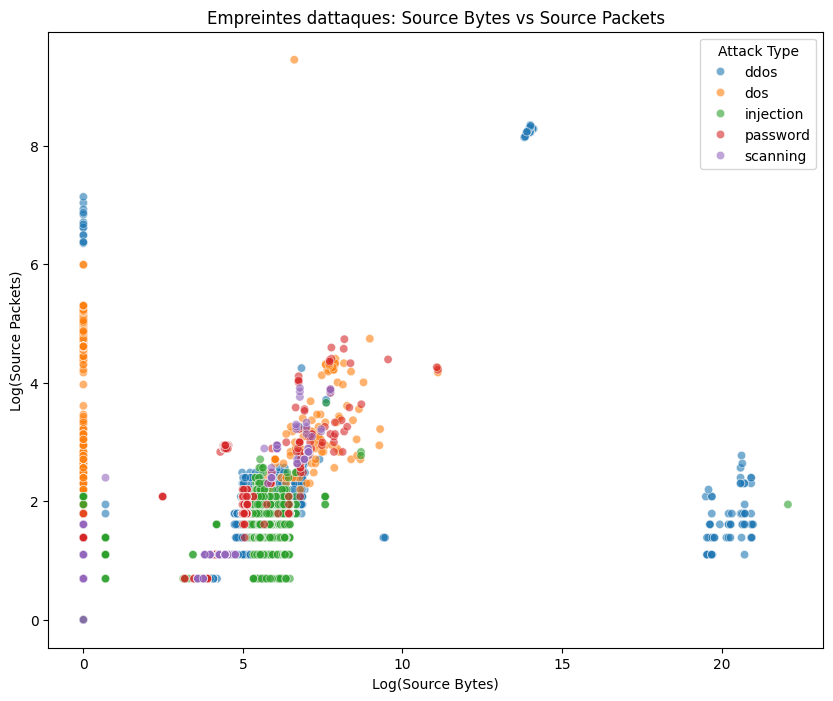

In [54]:
attacks_only = df[df['label'] == 1].copy()

top_attack_types = attacks_only['type'].value_counts().nlargest(5).index
attacks_filtered = attacks_only[attacks_only['type'].isin(top_attack_types)].copy()

attacks_filtered['log_src_bytes'] = np.log1p(attacks_filtered['src_bytes'])
attacks_filtered['log_src_pkts'] = np.log1p(attacks_filtered['src_pkts'])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=attacks_filtered, 
    x='log_src_bytes', 
    y='log_src_pkts', 
    hue='type', 
    palette='tab10',
    alpha=0.6
)
plt.title('Empreintes dattaques: Source Bytes vs Source Packets')
plt.xlabel('Log(Source Bytes)')
plt.ylabel('Log(Source Packets)')
plt.legend(title='Attack Type')
plt.show()

### Analyse Visuelle : Signatures et Empreintes des attaques

Ce nuage de points (Volume d'octets vs Nombre de paquets, en échelle logarithmique) me confirme que les attaques réseau présentent des profils très hétérogènes. Voici mes trois observations majeures :

1. **Le "Mur du zéro octet" (Axe X = 0) :**
   J'observe une ligne verticale très dense sur la gauche du graphique, dominée par les attaques DoS, DDoS et Scanning. Ces flux correspondent à des paquets totalement vides (0 octet de charge utile). C'est la signature classique des attaques par inondation (flooding), qui visent à épuiser les ressources d'un serveur (comme un TCP SYN Flood) sans transférer de données réelles.

2. **Le chevauchement central :**
   Au centre du graphique, je repère une vaste zone de chevauchement où se mélangent presque toutes les classes : attaques sur mots de passe, injections, scans et DoS. Dans ce périmètre précis, le comportement volumétrique de ces attaques est malheureusement indifférenciable de nombreuses requêtes légitimes. 

3. **Les signatures volumétriques extrêmes (Outliers) :**
   Les attaques DDoS forment des clusters isolés très spécifiques. Par exemple, le groupe situé à l'extrême droite représente des attaques transférant des volumes de données gigantesques. Un autre cluster, situé très haut sur l'axe Y, illustre quant à lui un déluge massif de paquets.

**Conclusion pour la modélisation :**
Ce graphique me prouve qu'**il est impossible de classer ces menaces en se basant uniquement sur la volumétrie**. À cause du fort chevauchement central, un algorithme simple serait incapable de faire la distinction entre une attaque *Password* et une *Injection*. Cela confirme ma stratégie : mon futur modèle d'apprentissage devra impérativement croiser simultanément l'ensemble des dimensions disponibles (protocoles, ports, statuts HTTP, etc.) pour réussir à "découper" ce nuage complexe et isoler les différentes menaces.

#### Matrice de Corrélation (Analyse des Redondances)

Dans le trafic réseau, plusieurs caractéristiques mesurent souvent le même phénomène. Par exemple, le nombre d'octets sources (`src_bytes`) et le nombre de paquets sources (`src_pkts`) évoluent généralement de manière simultanée. 

Ce bloc de code génère une **carte de chaleur (heatmap) des corrélations** pour me permettre d'identifier ces redondances mathématiques (la multicolinéarité) :

1. **Filtrage des données :** J'isole uniquement les variables numériques et j'exclus la variable cible (`label`) pour ne pas fausser l'analyse.
2. **Calcul et Masquage :** Je calcule la matrice de corrélation et j'applique un masque triangulaire (`np.triu`) pour cacher la moitié supérieure diagonale du graphique. Cela évite d'afficher l'information en double et clarifie la lecture.
3. **Interprétation :** * Les couleurs **rouges foncées** (proches de 1.0) ou **bleues foncées** (proches de -1.0) signalent des variables fortement corrélées. 
   * Si deux variables sont corrélées à 99 %, elles apportent exactement la même information. Repérer ces paires me permettra, par la suite, de supprimer les variables redondantes afin d'alléger mon modèle et d'accélérer son entraînement sans perte de précision.

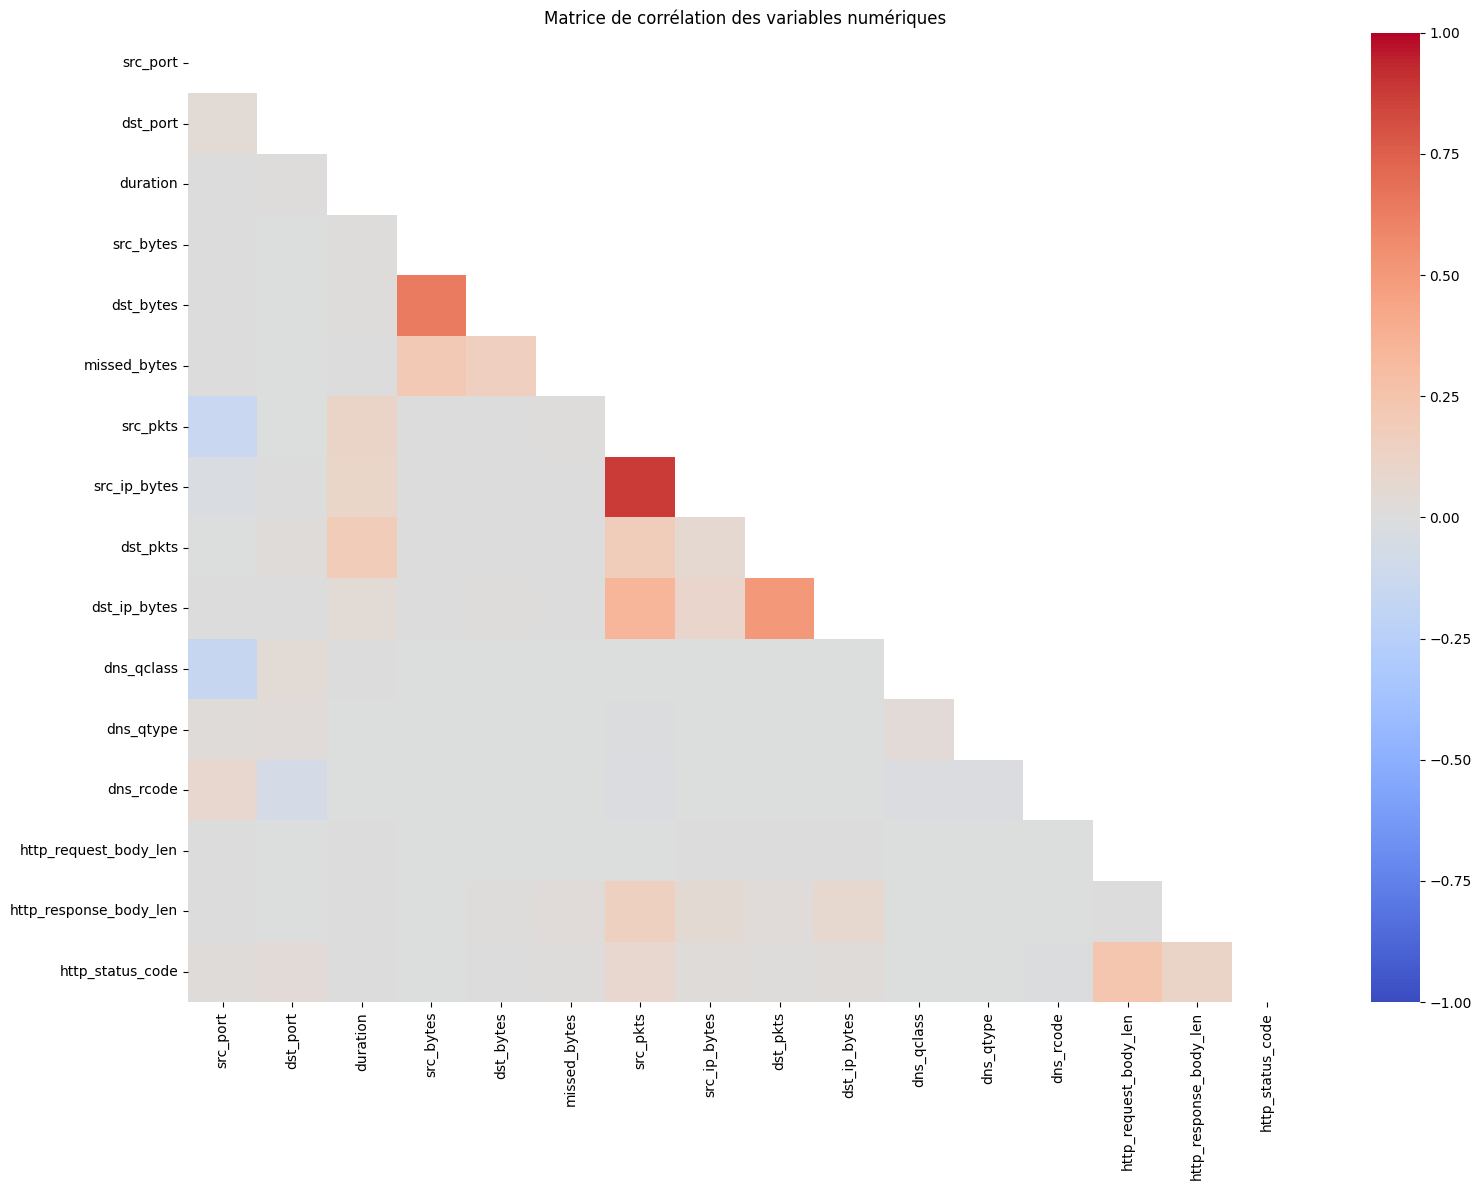

In [51]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['label'], errors='ignore')

plt.figure(figsize=(16, 12))
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

### Analyse des Redondances (Résultats de la Matrice)

Cette carte de chaleur met en évidence les relations mathématiques entre les caractéristiques de mon jeu de données. L'échelle varie de -1.0 (corrélation négative parfaite, en bleu) à 1.0 (corrélation positive parfaite, en rouge foncé), le zéro indiquant une absence de corrélation.

Voici mes principales observations :

1. **Indépendance globale (Dominance du gris) :**
   La matrice est majoritairement grise. Cela indique que la plupart de mes variables mesurent des aspects distincts du trafic (par exemple, le statut HTTP n'a pas de lien direct avec le port source). Mon modèle s'appuiera donc sur des informations uniques et variées.

2. **Forte multicolinéarité (Zones rouges et oranges) :**
   Je repère cependant quelques paires de variables fortement corrélées, ce qui signale une redondance d'information :
   * **`src_pkts` et `src_ip_bytes` :** C'est la corrélation la plus élevée. Il est logique que le nombre de paquets émis par la source soit proportionnel au volume d'octets IP envoyés.
   * **`dst_pkts` et `dst_ip_bytes` :** Ce même phénomène logique s'observe du côté de la destination.
   * **`src_bytes` et `dst_bytes` :** Cette corrélation positive montre que les connexions émettant beaucoup de données en reçoivent souvent beaucoup en retour.

3. **Conclusion et plan d'action :**
   Puisque `src_pkts` et `src_ip_bytes` fournissent quasiment la même information mathématique, conserver les deux n'apporte rien au modèle et risque de le ralentir. Pour optimiser mon pipeline d'apprentissage, je prévois de supprimer l'une des variables au sein de ces paires redondantes (par exemple, retirer `src_ip_bytes` au profit de `src_pkts`).

### Phase de validation : Séparabilité mathématique (PCA en 2D)

Avec plus de 40 caractéristiques, il m'est impossible de visualiser directement les relations entre les variables. Avant d'entraîner mon modèle prédictif, j'utilise l'Analyse en Composantes Principales (PCA) pour réduire la dimensionnalité de mes données numériques à 2 axes (Composantes Principales 1 et 2), tout en conservant un maximum de variance, afin de vérifier si les données sont mathématiquement séparables.

**Étapes clés de mon approche :**
1. **Échantillonnage :** J'extrais un sous-ensemble aléatoire de 15 000 lignes pour optimiser le temps de calcul et éviter de saturer la mémoire lors de la génération du graphique.
2. **Mise à l'échelle :** L'algorithme PCA étant très sensible aux différences d'échelle, j'applique un `StandardScaler`. Cela empêche les variables ayant de très grandes valeurs (comme le volume d'octets) de dominer la projection au détriment des autres.
3. **Projection visuelle :** L'objectif de ce graphique 2D est d'observer la répartition du trafic normal (points bleus) par rapport aux attaques (points rouges). Si ces deux catégories forment des zones ou des clusters distincts, cela confirme que les attaques possèdent une signature mathématique détectable, validant ainsi la pertinence d'entraîner un modèle de machine learning sur ce jeu de données.

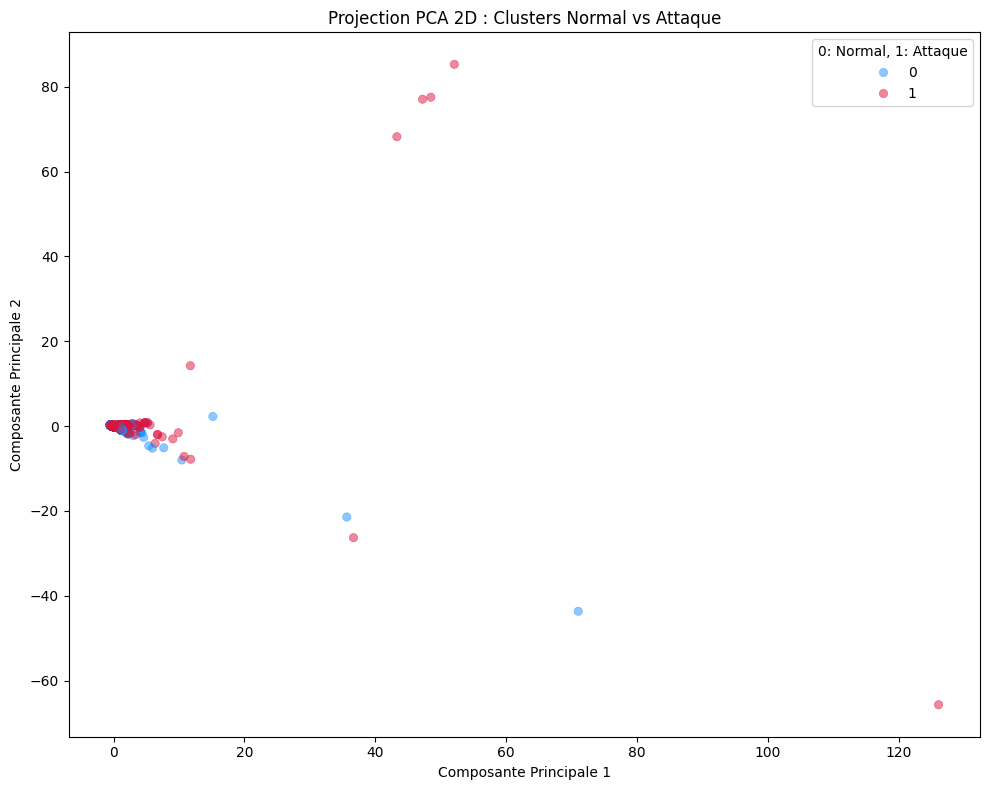

In [50]:
pca_df = df.sample(n=15000, random_state=42).copy()

numeric_pca = pca_df.select_dtypes(include=['int64', 'float64']).drop(columns=['label'], errors='ignore')
numeric_pca = numeric_pca.fillna(0)

scaler_pca = StandardScaler()
numeric_pca_scaled = scaler_pca.fit_transform(numeric_pca)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_pca_scaled)

pca_df['PCA1'] = pca_result[:, 0]
pca_df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='label',
    palette={0: 'dodgerblue', 1: 'crimson'},
    data=pca_df,
    alpha=0.5,
    edgecolor=None
)
plt.title('Projection PCA 2D : Clusters Normal vs Attaque')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend(title='0: Normal, 1: Attaque')
plt.tight_layout()
plt.show()

### Analyse de la Séparabilité (Résultat PCA)

Cette projection en 2 dimensions (Composante Principale 1 vs 2) révèle la structure mathématique de mon trafic réseau et guide ma stratégie de modélisation :

1. **Le cœur dense (Chevauchement) :** La majorité des points, tant légitimes (bleus) que malveillants (rouges), sont agglomérés dans un amas très dense près de l'origine. Cela indique qu'une grande partie des attaques imite les caractéristiques du trafic normal. Ce chevauchement massif montre qu'une séparation géométrique simple sera inefficace pour identifier les attaques furtives, géométriquement noyées dans le trafic légitime.

2. **Les signatures distinctives (Valeurs extrêmes) :** Je remarque que plusieurs points rouges (attaques) se détachent radicalement de l'amas central (vers Y = 80 ou X = 120). Ces points correspondent très probablement à des attaques volumétriques (comme des DDoS ou des scans massifs) qui génèrent une variance mathématique extrême et facilement identifiable.

3. **Conclusion sur la modélisation à venir :** Ce graphique démontre de façon flagrante que mes classes ne sont **pas linéairement séparables** (il est impossible de tracer une simple ligne droite pour isoler les points bleus des rouges). Cette observation m'indique qu'un modèle d'apprentissage basique (comme une régression logistique) va échouer. Pour la suite de ce projet, je vais devoir expérimenter des algorithmes d'intelligence artificielle plus avancés, capables d'apprendre des frontières de décision hautement non linéaires, pour espérer "découper" ce nuage complexe et isoler les menaces.

## 3. Pipeline de Préparation des Données

### 3.1. Phase de prétraitement : Transformation et ingénierie des données

Ce bloc de code constitue le cœur de mon pipeline de préparation. Il transforme mes données brutes en une matrice mathématique optimisée pour l'entraînement de mes futurs modèles d'apprentissage. Ce processus se déroule en 5 étapes clés :

1. **Prévention des fuites de données (Data Leakage) :** Je supprime les adresses IP et les ports (`src_ip`, `dst_ip`, `src_port`, `dst_port`), ainsi que l'étiquette binaire (`label`). Si je conservais les adresses IP, le modèle se contenterait de mémoriser quelles machines ont été attaquées dans ce laboratoire spécifique, au lieu d'apprendre à reconnaître la signature comportementale universelle d'une attaque.
2. **Encodage de la cible (Target Variable) :** Les algorithmes ne comprenant pas le texte, j'utilise un `LabelEncoder` pour convertir ma cible multiclasse (la colonne `type`, qui contient "ddos", "backdoor", etc.) en un vecteur d'entiers allant de 0 à 9.
3. **Ingénierie des variables catégorielles (One-Hot Encoding) :** Pour les caractéristiques textuelles (comme les protocoles ou les services), je remplace d'abord les valeurs manquantes par la chaîne "None". Ensuite, j'applique un encodage "One-Hot" (`pd.get_dummies`). Cela transforme chaque catégorie en colonnes binaires (0 ou 1), évitant ainsi au modèle de déduire faussement qu'un protocole aurait une valeur mathématique supérieure à un autre.
4. **Nettoyage et mise à l'échelle (Standard Scaling) :** Je comble toutes les valeurs numériques manquantes par 0. Ensuite, j'applique un `StandardScaler` pour centrer et réduire les données (moyenne de 0, écart-type de 1). Cette étape est indispensable : sans elle, les variables atteignant des millions d'octets écraseraient mathématiquement celles avec de petites valeurs, comme la durée de connexion.
5. **Optimisation de la mémoire (Casting) :** Enfin, je convertis la matrice résultante (`X_scaled`) du format par défaut (`float64`) vers un format plus léger (`float32`). Cela divise par deux la consommation de ma mémoire vive (RAM/VRAM) sans perte de précision significative, une optimisation incontournable pour entraîner mes modèles de manière fluide.





In [55]:
leakage_cols = ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'label']
columns_to_drop = [col for col in leakage_cols if col in df.columns]

X = df.drop(columns=columns_to_drop)

le_type = LabelEncoder()
y = le_type.fit_transform(X['type'])
X = X.drop(columns=['type'])

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X[col] = X[col].fillna('None').astype(str)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = X_scaled.astype(np.float32)

#### Vérification de la variance nulle (Zero-Variance Check)

Avant de transmettre mes matrices de données aux modèles d'apprentissage, je dois m'assurer que chaque caractéristique (colonne) apporte une véritable information mathématique.

Ce test de **variance nulle** vise à identifier les colonnes où toutes les lignes possèdent exactement la même valeur (par exemple, un indicateur réseau toujours inactif sur l'intégralité du trafic capturé).

**Objectif opérationnel :** Un algorithme de machine learning construit ses règles de décision en observant des *variations*. Une variable constante n'a donc **aucun pouvoir prédictif**. Elle ne fait qu'augmenter inutilement la dimensionnalité du problème, ralentissant l'entraînement et favorisant le bruit. Cette étape agit comme un audit de conformité : elle me permet de purger le jeu de données de tout "poids mort" algorithmique avant d'entamer la modélisation.

In [49]:
print("--- Vérification de la variance nulle ---")

unique_counts = df.nunique()
zero_variance_cols = unique_counts[unique_counts == 1].index.tolist()

print(f"Nombre total de colonnes avec une seule valeur unique : {len(zero_variance_cols)}")

if len(zero_variance_cols) > 0:
    print(f"Ces colonnes n'apportent aucun pouvoir prédictif et doivent être supprimées : {zero_variance_cols}")
else:
    print("Aucune colonne à variance nulle détectée. Toutes les caractéristiques contiennent de l'information.")

--- Vérification de la variance nulle ---
Nombre total de colonnes avec une seule valeur unique : 0
Aucune colonne à variance nulle détectée. Toutes les caractéristiques contiennent de l'information.


### Résultat de la validation : Test de variance nulle concluant

**Interprétation du résultat :**
Le test affiche un résultat optimal (`Nombre total de colonnes avec une seule valeur unique : 0`). Cela me confirme que mon jeu de données est dense, bien structuré et hautement qualitatif.

* **Absence de données "mortes" :** Chaque colonne contient au moins deux valeurs distinctes. Mon dataset ne comporte aucune variable statique ou constante qui viendrait alourdir inutilement les calculs de l'algorithme.
* **Potentiel prédictif total :** Puisque toutes mes caractéristiques varient, elles offrent toutes des signaux mathématiques exploitables. C'est ce qui permettra au modèle de séparer avec précision le trafic légitime des attaques complexes.
* **Conclusion :** Je n'ai aucune suppression de caractéristique à effectuer lors de cette étape. Je valide cette phase et j'avance vers la modélisation avec la certitude que 100 % de mes variables d'entrée sont pertinentes et utiles.

### 3.2. Phase de préparation : Fractionnement et Formatage

Avant d'entraîner mon modèle, je dois isoler un jeu de test et adapter le format mathématique de mes données. Ce bloc de code effectue trois opérations clés :

1. **Fractionnement Train/Test :** J'utilise `train_test_split` pour diviser mon dataset : 80 % pour l'entraînement (`X_train`) et 20 % pour le test (`X_test`). Je mets ces 20 % de côté pour qu'ils ne soient jamais vus par le modèle durant l'apprentissage. Cela me permettra d'évaluer sa réelle capacité à détecter de nouvelles attaques, sans qu'il ne se contente de mémoriser les données (prévention du surapprentissage).

2. **Reshaping tensoriel :** Mes données tabulaires sont initialement en 2 dimensions. Or, les couches de convolution 1D (`Conv1D`) que j'utilise pour cette expérimentation exigent un tenseur en 3 dimensions : `(Taille du Batch, Nombre de Caractéristiques, Nombre de Canaux)`. J'applique donc `np.expand_dims(..., axis=2)` pour ajouter cette troisième dimension, rendant ainsi mes données compatibles avec l'architecture du réseau de neurones.

3. **Définition dynamique des classes :** Je calcule le nombre de classes uniques (`num_classes`) directement à partir des données d'entraînement. Cette variable me permet de définir automatiquement le nombre exact de neurones requis pour la dernière couche de classification (`Softmax`) de mon modèle.

In [56]:
X_train_full, X_test_full, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_final = np.expand_dims(X_train_full, axis=2)
X_test_final = np.expand_dims(X_test_full, axis=2)
num_classes = len(np.unique(y_train))

## 4. Modélisation et Évaluation

### 4.1. Réseau de Neurones Convolutif (CNN 1D)

Dans cette phase, je construis mon premier modèle de Deep Learning avec TensorFlow/Keras pour apprendre les signatures des attaques réseau. J'implémente ici plusieurs techniques d'optimisation pour maximiser la détection :

1. **La fonction de perte focale (Focal Loss) :** Mon EDA a révélé un déséquilibre de classe massif (ex. : seulement 1 041 attaques MITM). Une perte classique (Cross-Entropy) inciterait le modèle à ignorer ces attaques rares. J'utilise donc une fonction personnalisée `categorical_focal_loss`. Son paramètre Gamma pénalise les erreurs sur les classes minoritaires et réduit l'importance des attaques faciles à classer (comme les DDoS massives), forçant ainsi le réseau à se concentrer sur les menaces furtives.

2. **L'architecture spatiale (CNN 1D) :** J'utilise un CNN 1D, une architecture très efficace pour analyser une séquence de caractéristiques réseau :
   * Mes couches `Conv1D` scannent les 44 variables pour en extraire des motifs de proximité (les signatures d'attaques).
   * Mes couches `BatchNormalization` stabilisent mathématiquement le réseau pour un apprentissage plus rapide et régulier.
   * J'ajoute une couche `Dropout (0.5)` qui désactive aléatoirement 50 % des neurones pendant l'entraînement. C'est mon mécanisme de régularisation pour empêcher le modèle d'apprendre les données par cœur (prévention du surapprentissage).

3. **Le contrôle de l'entraînement (Callbacks) :** Pour encadrer et stabiliser l'apprentissage de mon réseau, je déploie trois callbacks :
   * **EarlyStopping :** J'interromps automatiquement l'entraînement si la perte de validation (`val_loss`) stagne pendant 5 cycles (epochs). Cela m'évite l'overfitting.
   * **ModelCheckpoint :** Je sauvegarde uniquement la meilleure version du modèle sur le disque, en ignorant les dégradations éventuelles en fin d'entraînement.
   * **ReduceLROnPlateau :** Si le modèle bloque sur un plateau et ne progresse plus, je divise dynamiquement son taux d'apprentissage par deux (`factor=0.5`) pour lui permettre d'affiner l'optimisation de ses poids.

In [57]:
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed

model = Sequential([
    Conv1D(filters=64, kernel_size=3, input_shape=(X_train_final.shape[1], 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=32, kernel_size=3),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_ids_model_multi.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)

history = model.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_test_final, y_test),
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6377 - loss: 0.1756 - val_accuracy: 0.7044 - val_loss: 0.0950 - learning_rate: 0.0010
Epoch 2/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7369 - loss: 0.0870 - val_accuracy: 0.7476 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 3/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7520 - loss: 0.0799 - val_accuracy: 0.7136 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 4/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7594 - loss: 0.0758 - val_accuracy: 0.5986 - val_loss: 0.1299 - learning_rate: 0.0010
Epoch 5/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7714 - loss: 0.0723 - val_accuracy: 0.6338 - val_loss: 0.1009 - learning_rate: 0.0010
Epoch 6/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7793 - loss: 0.0691 - val_accuracy: 0.7517 - val_loss: 0.0691 - learning_rate: 5.0000e-04
Epoch 7/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7884

### 4.2. Analyse des logs d'entraînement (CNN 1D)

L'analyse de l'entraînement de mon modèle me permet d'évaluer son comportement et mes choix d'architecture :

1. **Accélération matérielle :**
   Les logs confirment que TensorFlow exploite correctement l'accélération matérielle (GPU) pour optimiser les temps de calcul, stabilisés à environ 10 secondes par itération (Epoch).

2. **Progression de l'apprentissage (Training) :**
   Le modèle assimile logiquement les données d'entraînement. La précision (`accuracy`) grimpe de 63,7 % à l'Epoch 1 pour dépasser les 80 % (80,6 %) à l'Epoch 9. Parallèlement, la perte d'entraînement (`loss`) baisse de manière continue (de 0.1756 à 0.0638). Le CNN réussit donc à mémoriser et à extraire des motifs pertinents sur les données d'entraînement.

3. **Instabilité de la validation et action des Callbacks :**
   Je constate cependant une forte instabilité sur les métriques de validation (`val_accuracy` et `val_loss`). Par exemple, la précision de validation chute brusquement à 59,8 % (Epoch 4), remonte à 79,1 % (Epoch 7), puis rechute à 65,0 % (Epoch 9). La perte de validation connaît les mêmes variations brusques (des pics à plus de 0.13). 
   Face à ce comportement erratique, mes mécanismes de contrôle ont réagi :
   * **ReduceLROnPlateau :** Constatant la dégradation de la validation, l'algorithme a automatiquement réduit le taux d'apprentissage. Il est passé de `0.0010` à `5.0000e-04` à l'Epoch 6, puis a de nouveau été divisé par deux (`2.5000e-04`) à l'Epoch 10 pour forcer des ajustements de poids plus fins.
   * **ModelCheckpoint & EarlyStopping :** La meilleure performance réelle observée sur cette séquence se situe à l'Epoch 12 (avec une `val_loss` minimale de 0.0599 et une précision de 80,4 %). C'est ce point optimal d'équilibre que le système restaure pour éviter d'intégrer le bruit des variations ultérieures.

**Bilan :**
Le réseau de neurones remplit son rôle d'extraction de caractéristiques via les couches de convolution, comme le prouve son apprentissage initial. Néanmoins, l'instabilité majeure observée sur le jeu de validation souligne la difficulté des architectures CNN (généralement prévues pour l'image ou le signal temporel continu) à généraliser de manière fluide sur des données de trafic réseau strictement tabulaires et fortement hétérogènes. Cette expérimentation valide donc pleinement ma stratégie de contrôle : sans l'intervention stricte de l'arrêt précoce (EarlyStopping) et de la sauvegarde ciblée (ModelCheckpoint), le modèle final aurait été fortement dégradé par ce bruit d'apprentissage.

### 4.3. Phase d'Évaluation : Performances du modèle CNN 1D

J'évalue maintenant la capacité de mon modèle à généraliser sur des données inédites (mon jeu de test de 20 %). Pour cela, je génère trois outils de diagnostic :

1. **Les courbes d'apprentissage (Learning Curves) :**
   * Je trace l'évolution de la précision (accuracy) et de la perte (loss) au fil des itérations (epochs).
   * Cela me permet d'auditer la stabilité de l'entraînement et de détecter un éventuel surapprentissage (overfitting). C'est aussi ici que j'observe visuellement l'intervention de mon `EarlyStopping`.

2. **Le rapport de classification (Classification Report) :**
   * Je lance les prédictions sur mon set de test (`X_test_final`).
   * J'analyse la **précision**, le **rappel (recall)** et le **F1-Score** pour chaque classe. Dans ce contexte de cybersécurité, mon objectif est d'obtenir un rappel très élevé pour m'assurer qu'aucune attaque ne passe sous le radar.

3. **La matrice de confusion (Confusion Matrix) :**
   * Elle croise la réalité (étiquettes réelles) avec les prédictions de mon modèle. La diagonale indique les prédictions correctes, tandis que les autres cases mettent en évidence mes erreurs de classification.
   * *Lien avec mon analyse exploratoire :* C'est ici que je vérifie si le modèle a réussi à démêler le fameux "cœur dense" identifié lors de mon ACP/PCA. Si je constate de fortes confusions (par exemple entre les attaques `dos` et `injection`), cela me confirmera les limites de l'architecture CNN face à des données tabulaires fortement superposées.

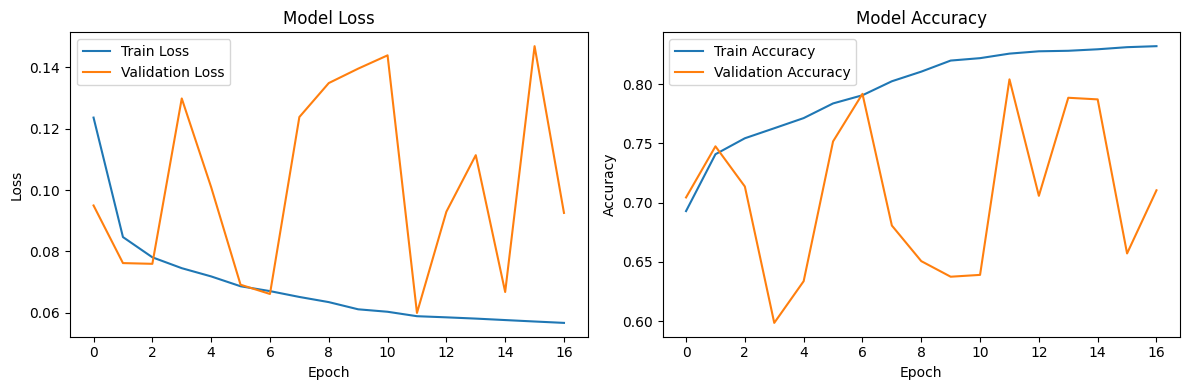

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

    backdoor       0.67      0.01      0.02      3714
        ddos       0.97      0.95      0.96      3993
         dos       0.39      0.94      0.55      3756
   injection       0.90      0.95      0.92      4078
        mitm       0.63      0.70      0.67       210
      normal       0.98      0.98      0.98      8389
    password       0.98      0.71      0.82      3948
  ransomware       0.96      0.81      0.88      2944
    scanning       0.86      0.80      0.83      4072
         xss       0.85      0.86      0.86      2991

    accuracy                           0.80     38095
   macro avg       0.82      0.77      0.75     38095
weighted avg       0.85      0.80      0.78     38095



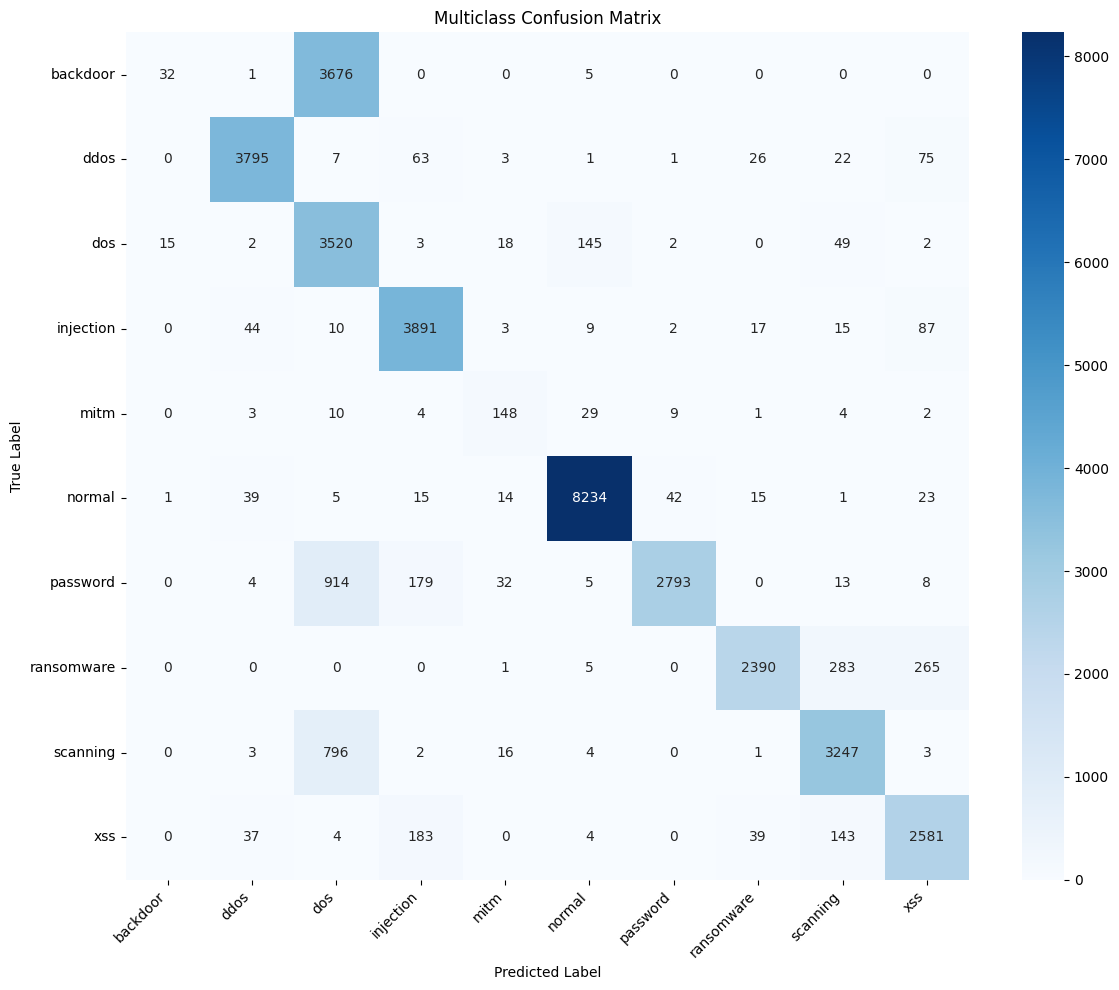

In [58]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = le_type.classes_

print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.4. Diagnostic des performances : Les limites du CNN sur les données tabulaires

L'évaluation de mon CNN 1D met en évidence la difficulté d'appliquer le Deep Learning pur à des données tabulaires. Si la précision globale atteint **80 %**, mon analyse détaillée révèle des défaillances critiques d'un point de vue opérationnel en cybersécurité :

1. **Instabilité de l'apprentissage (Courbes Loss/Accuracy) :**
   Les courbes d'entraînement indiquent que le modèle apprend de manière continue sur le set de Train. Cependant, les courbes de validation sont chaotiques, avec des dégradations brutales (la `val_accuracy` s'effondre autour de 60 % dès l'Epoch 3, puis subit de fortes variations en dents de scie jusqu'à la fin). Cette volatilité prouve que mon réseau peine à définir des frontières de décision stables pour généraliser sur de nouvelles données.

2. **Biais de prédiction vers la classe DoS (Matrice de confusion) :**
   La matrice de confusion révèle un défaut structurel majeur : le modèle utilise la classe `dos` comme une catégorie "fourre-tout" lorsqu'il n'arrive pas à statuer. Il classe par erreur **3 676** attaques `backdoor`, **914** attaques `password` et **796** attaques `scanning` en tant que `dos`. Cela confirme l'hypothèse soulevée lors de mon analyse exploratoire (PCA) : face au "cœur dense" où les classes se chevauchent fortement, le CNN échoue à isoler les signaux spécifiques.

3. **Échec sur les attaques furtives (Rapport de classification) :**
   Les métriques intra-classes traduisent mathématiquement ces confusions :
   * **Chute du rappel (Recall) :** Le modèle ne détecte que **1 % (0.01)** des attaques `backdoor` et **71 % (0.71)** des attaques `password`. Dans un contexte réel de cybersécurité, rater 99 % d'un type de porte dérobée n'est absolument pas viable. À l'inverse, la précision pour la classe `dos` s'effondre à **39 % (0.39)** car elle est polluée par toutes ces fausses alertes.
   * **Détection du trafic légitime :** Le modèle identifie en revanche excellemment bien le trafic normal (Précision de 0.98, Rappel de 0.98, F1-Score de **0.98**). Il n'est donc pas techniquement défaillant dans sa globalité, mais sa méthode d'apprentissage spatiale est inadaptée à la classification multiclasse de menaces imbriquées.

**Conclusion :**
Cette expérimentation démontre empiriquement la limite du modèle : l'optimisation continue des réseaux de neurones est ici prise en défaut par la structure de mes données tabulaires. L'approche mathématique spatiale du CNN s'avère inadaptée pour isoler efficacement les menaces furtives au sein de ce dataset.

### 4.5. Pivot technologique : Transition vers un Réseau de Neurones Dense (DNN)

Mon expérimentation avec le CNN 1D a mis en évidence des lacunes dans la détection des attaques furtives. Mon hypothèse est la suivante : si les couches de convolution (Conv1D) excellent pour extraire des motifs de proximité, ma matrice de corrélation a démontré que mes variables sont majoritairement indépendantes. Le CNN a donc probablement cherché des relations spatiales ou géométriques inexistantes entre mes colonnes.

Pour valider cette hypothèse, je déploie une architecture plus classique et généralement plus robuste pour le traitement de données tabulaires : un **Réseau de Neurones Dense (DNN - Deep Neural Network)**.

**Objectif du DNN :** Contrairement au CNN qui effectue un balayage local, chaque neurone d'une couche dense est connecté à l'ensemble des caractéristiques en entrée. Mon but est de forcer le modèle à évaluer chaque connexion réseau dans sa globalité (les 44 dimensions simultanément), indépendamment de l'ordre ou de la disposition géométrique des variables.

### 4.6. Phase de Modélisation : Architecture DNN

Ce bloc de code définit la structure de mon réseau dense. Contrairement à l'expérimentation précédente avec le CNN, mes données d'entrée (`X_train_full`) conservent leur format tabulaire natif et ne nécessitent aucun redimensionnement 3D.

1. **Nettoyage de l'environnement :** J'exécute d'abord `tf.keras.backend.clear_session()`. C'est une étape indispensable pour purger la mémoire du GPU de toute trace (poids, graphes) de l'ancien modèle CNN, évitant ainsi les conflits ou les ralentissements.

2. **Architecture en entonnoir :** J'implémente une structure séquentielle décroissante (256 neurones -> 128 -> 64). Cette compression spatiale force le modèle à extraire l'essence mathématique des caractéristiques.
   * **BatchNormalization & ReLU :** Je les utilise pour stabiliser les valeurs et accélérer l'apprentissage.
   * **Dropout (0.3) :** J'ajoute cette couche pour désactiver aléatoirement 30 % des neurones à chaque passage. Cela empêche le modèle d'apprendre par cœur et favorise sa capacité de généralisation.

3. **Stratégie d'apprentissage (Callbacks) :** Je maintiens ma fonction de perte focale (Focal Loss) pour contrer le déséquilibre des classes. J'augmente également le nombre d'itérations (`epochs=100`) et la patience de l'`EarlyStopping` (`patience=10`) afin de laisser au DNN plus de temps pour stabiliser ses prédictions.

In [59]:
tf.keras.backend.clear_session()

dnn_model = Sequential([
    Dense(256, input_shape=(X_train_full.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

dnn_model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

dnn_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
dnn_checkpoint = ModelCheckpoint('best_ids_model_dnn.keras', monitor='val_loss', save_best_only=True)
dnn_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

dnn_history = dnn_model.fit(
    X_train_full, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_test_full, y_test),
    callbacks=[dnn_early_stop, dnn_checkpoint, dnn_reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.5897 - loss: 0.1970 - val_accuracy: 0.7326 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 2/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7159 - loss: 0.0891 - val_accuracy: 0.7333 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 3/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7200 - loss: 0.0832 - val_accuracy: 0.7334 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 4/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7246 - loss: 0.0810 - val_accuracy: 0.7328 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 5/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7255 - loss: 0.0797 - val_accuracy: 0.7340 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 6/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7211 - loss: 0.0792 - val_accuracy: 0.7211 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 7/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7258 - loss: 

### 4.7. Analyse des logs d'entraînement (DNN) : Diagnostic du surapprentissage

L'entraînement sur 21 itérations (Epochs) met en évidence des comportements algorithmiques clairs et valide l'utilisation de mes mécanismes de contrôle (callbacks) :

1. **Efficacité computationnelle :** Chaque itération ne prend plus qu'environ 3 secondes (contre une dizaine de secondes pour le CNN, après la première itération d'initialisation). Mon architecture Dense, bien qu'analysant les données globalement, est mathématiquement plus légère et plus rapide à exécuter que les filtres de convolution.

2. **Divergence et surapprentissage (Overfitting) :**
   Les métriques d'entraînement (`accuracy` et `loss`) s'améliorent logiquement : la précision monte à plus de 75 % (0.7525 à l'Epoch 20) et la perte diminue constamment. En revanche, sur le jeu de validation (`val_loss`), le modèle atteint son pic de performance à l'Epoch 11 (perte minimale de 0.0722 pour une précision de 73,9 %). À partir de l'Epoch 14, la perte de validation recommence fortement à augmenter (atteignant 0.1230 à l'Epoch 21) et la précision chute sévèrement (jusqu'à 63,1 %). J'observe ici un cas clair d'overfitting : le modèle commence à mémoriser les données d'entraînement au lieu d'apprendre à généraliser.

3. **Intervention des Callbacks :**
   Face à cette divergence, mes mécanismes de régulation ont réagi avec précision :
   * **ReduceLROnPlateau :** Suite à la dégradation de la validation, l'algorithme a réduit son taux d'apprentissage à l'Epoch 14 (passant de `0.0010` à `5.0000e-04`) pour forcer des ajustements de poids plus fins. Il a répété cette division par deux à l'Epoch 17 (`2.5000e-04`), puis à l'Epoch 20 (`1.2500e-04`).
   * **EarlyStopping :** La limite de patience (10) ayant été atteinte face à la dégradation continue de la `val_loss`, l'entraînement s'est interrompu de lui-même à l'Epoch 21. L'option `restore_best_weights=True` a automatiquement annulé les itérations divergentes pour restaurer les poids optimaux de l'Epoch 11.

**Bilan :** Le DNN s'entraîne plus rapidement, mais son incapacité à généraliser au-delà de l'Epoch 11 me confirme que les réseaux de neurones (qu'ils soient spatiaux avec le CNN ou globaux avec le DNN) peinent à extraire des frontières de décision stables sur la structure de mes données tabulaires sans un contrôle strict du surapprentissage.

### 4.8. Diagnostic final (DNN) : Évaluation complète des performances

Maintenant que l'entraînement de mon modèle Dense (DNN) est terminé et que ses poids optimaux ont été restaurés par les callbacks, j'évalue ses performances réelles sur mon jeu de test (les 20 % de données inédites).

Ce bloc de code exécute trois opérations d'évaluation à la suite :

1. **Les courbes d'apprentissage (Learning Curves) :** Je trace l'évolution de la perte (`loss`) et de la précision (`accuracy`) pour visualiser graphiquement le phénomène de surapprentissage diagnostiqué lors de l'entraînement.
2. **Prédictions probabilistes et Rapport de classification :** Le modèle analyse chaque connexion du jeu de test. J'utilise la fonction `argmax` pour convertir les probabilités générées par `predict` en prédictions finales. Je génère ensuite les métriques détaillées (Précision, Rappel, F1-Score) pour chaque classe.
3. **La matrice de confusion :** Je trace une carte de chaleur (heatmap) croisant la réalité avec les prédictions du modèle pour identifier visuellement les éventuelles confusions entre les différentes classes d'attaques.

**Objectif de l'évaluation :**
Je dois vérifier si le DNN, grâce à son architecture globale, parvient à corriger les échecs du CNN. Je vais analyser avec attention les résultats associés aux attaques furtives (notamment `backdoor` et `password`). Si leur rappel (recall) reste faible, cela me confirmera que la difficulté ne provient pas du choix de l'architecture du réseau, mais bien des limites inhérentes du Deep Learning face à la structure spécifique de mes données tabulaires (chevauchement des classes).

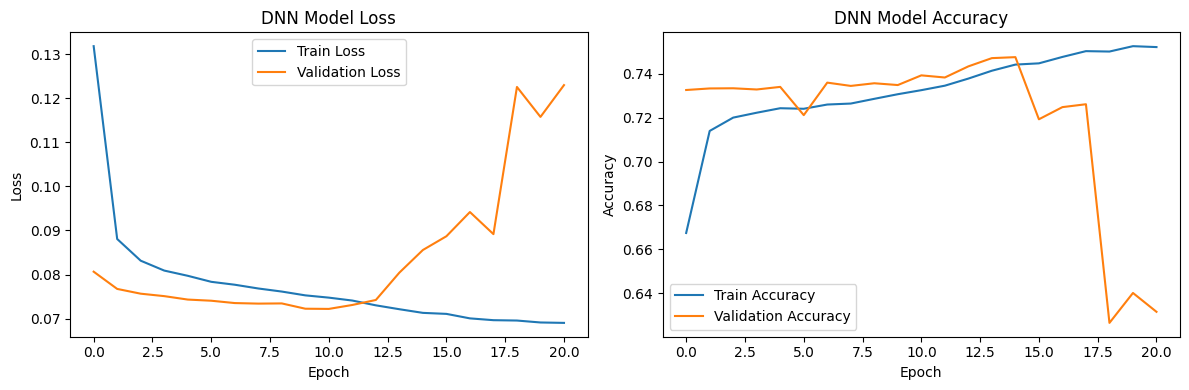

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
--- DNN Classification Report ---
              precision    recall  f1-score   support

    backdoor       0.44      1.00      0.61      3714
        ddos       0.98      0.91      0.94      3993
         dos       0.88      0.12      0.20      3756
   injection       0.54      0.91      0.68      4078
        mitm       0.61      0.72      0.66       210
      normal       0.97      0.98      0.97      8389
    password       0.99      0.05      0.10      3948
  ransomware       0.94      0.81      0.87      2944
    scanning       0.81      0.80      0.80      4072
         xss       0.75      0.82      0.79      2991

    accuracy                           0.74     38095
   macro avg       0.79      0.71      0.66     38095
weighted avg       0.83      0.74      0.70     38095



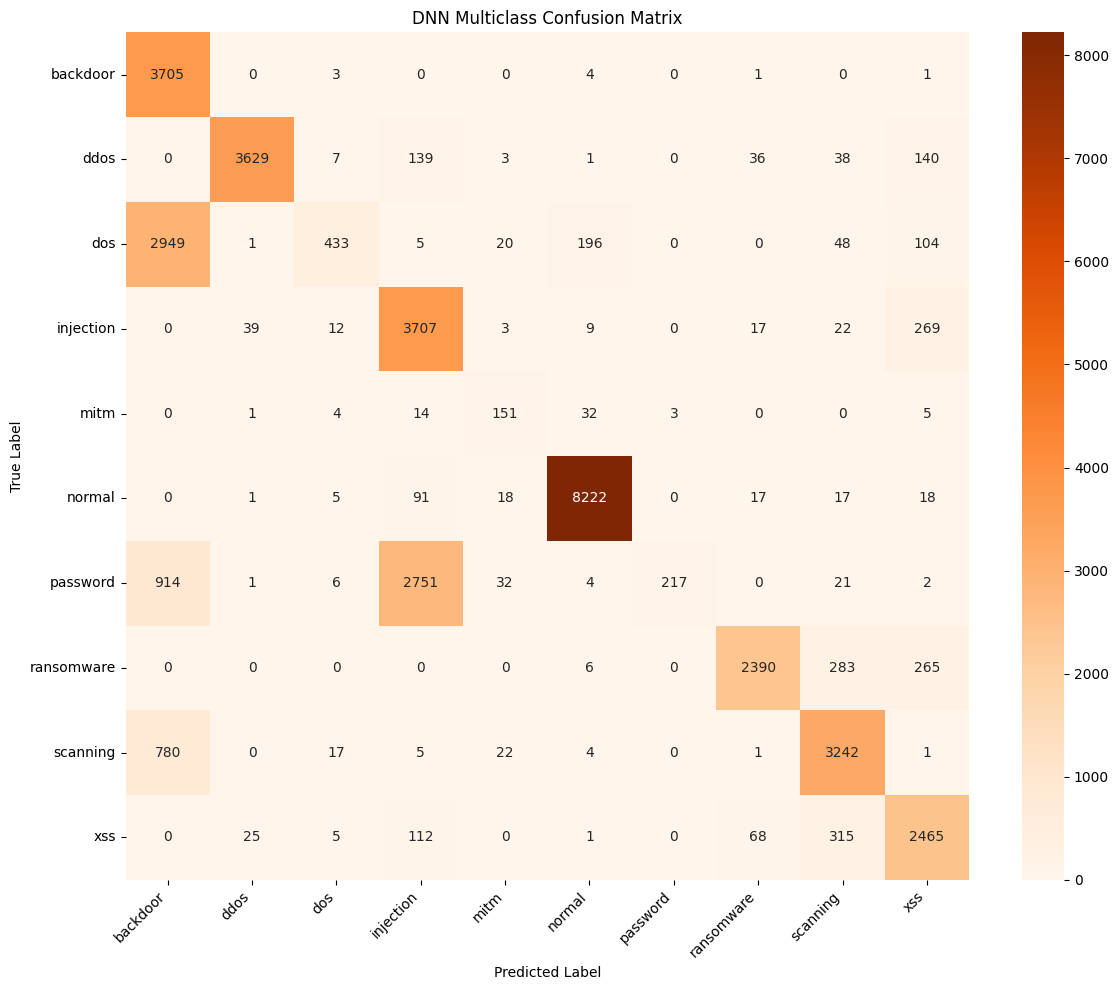

In [60]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(dnn_history.history['loss'], label='Train Loss')
plt.plot(dnn_history.history['val_loss'], label='Validation Loss')
plt.title('DNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(dnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

dnn_y_pred_probs = dnn_model.predict(X_test_full)
dnn_y_pred = np.argmax(dnn_y_pred_probs, axis=1)

print("--- DNN Classification Report ---")
print(classification_report(y_test, dnn_y_pred, target_names=target_names))

dnn_cm = confusion_matrix(y_test, dnn_y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(dnn_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DNN Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.9. Diagnostic final (DNN) : Analyse des performances et limites

L'évaluation finale de mon Réseau de Neurones Dense (DNN) indique une précision globale de **74 %**, échouant ainsi à surpasser les performances du CNN. L'analyse détaillée par classe montre que la difficulté de classification n'a pas été résolue, elle a simplement été déplacée :

1. **Biais de sur-prédiction sur la classe `backdoor` :**
   À première vue, le rappel (recall) de cette classe furtive passe de 1 % (avec le CNN) à **100 % (1.00)**. Cependant, la précision associée s'effondre à **0.44 (44 %)**. Face à la complexité des données, le DNN n'est pas parvenu à isoler la signature exacte des backdoors : il a classé massivement le trafic ambigu dans cette catégorie pour maximiser le rappel (comme le montre la matrice de confusion avec 2 949 attaques `dos` et 780 `scanning` classées à tort comme `backdoor`), générant un taux très important de faux positifs.

2. **Chute des performances sur les autres attaques :**
   Conséquence directe de ces biais, le modèle a perdu sa capacité à détecter d'autres attaques critiques :
   * Le rappel des attaques `dos` a chuté à **12 % (0.12)**.
   * Le rappel des attaques `password` est tombé à **5 % (0.05)** (la matrice révèle que le DNN les confond massivement avec la classe `injection`).
   Le modèle ne parvient toujours pas à établir des frontières de décision nettes dans la zone de chevauchement (le "cœur dense") observée lors de mon analyse exploratoire (ACP).

3. **Stabilité sur le trafic normal :**
   Le modèle maintient d'excellentes performances pour identifier le trafic `normal` (Précision de 0.97, Rappel de 0.98). Il réussit à séparer le trafic légitime du trafic malveillant au sens large, mais échoue dans la classification multiclasse précise des menaces.

**Conclusion et ultime tentative Deep Learning :**
Ces résultats me confirment de manière empirique que l'approche mathématique d'un réseau de neurones simple (qu'il soit purement spatial ou purement dense) est inadaptée à ces données tabulaires fortement imbriquées. Cependant, avant d'abandonner définitivement le Deep Learning au profit d'algorithmes ensemblistes (comme XGBoost), je souhaite mener une ultime expérimentation : fusionner les capacités d'extraction locale du CNN avec la vision globale du DNN au sein d'une architecture hybride.

### 4.10. Phase de Modélisation : Architecture hybride (CNN + DNN)

Mes expérimentations précédentes ont mis en évidence les limites spécifiques à chaque architecture :
* Le **CNN** réussit à extraire des motifs de proximité (relations locales entre les variables) mais manque de vision d'ensemble.
* Le **DNN** analyse correctement les caractéristiques dans leur globalité, mais ignore les nuances locales, ce qui a entraîné un biais de sur-prédiction sur certaines classes furtives.

**Hypothèse et mise en œuvre :**
Pour pallier ces limites, mon hypothèse est de combiner les forces de ces deux approches. Je conçois ici un réseau de neurones à entrées multiples (Multi-Input Network). 

L'architecture s'appuie sur deux branches fonctionnant en parallèle : une branche convolutive (CNN) chargée d'isoler les signaux locaux, et une branche dense (DNN) chargée d'évaluer l'attaque dans sa globalité. Les représentations mathématiques issues de ces deux branches sont ensuite fusionnées (concaténées) avant de traverser les dernières couches de classification. Cette approche hybride constitue ma dernière expérimentation pour tenter de repousser les limites du Deep Learning sur la structure de ces données tabulaires.

### 4.11. Construction du réseau hybride (API Fonctionnelle Keras)

Pour concevoir ce modèle à entrées multiples, j'abandonne l'approche `Sequential` classique au profit de l'API Fonctionnelle de Keras (TensorFlow). Ce bloc de code définit l'architecture suivante :

1. **La branche spatiale (CNN) :** J'injecte les données au format 3D (`X_train_final`) dans un bloc convolutif. Les couches `Conv1D` et `MaxPooling1D` extraient les motifs locaux, puis le résultat est aplati en un vecteur via une couche `Flatten`.

2. **La branche globale (DNN) :** En parallèle, je passe mes données tabulaires classiques 2D (`X_train_full`) dans un réseau dense. Les couches `Dense` de 128 et 64 neurones traitent l'information dans sa globalité, associées à du `Dropout` pour limiter le surapprentissage.

3. **La fusion des caractéristiques (Concatenation) :** J'utilise `Concatenate()([out_cnn, out_dnn])` pour fusionner les représentations mathématiques issues des branches CNN et DNN en un vecteur unique.

4. **La tête de classification :** Ce vecteur unifié traverse une dernière couche `Dense` de 128 neurones avant d'atteindre la couche de sortie `softmax`, qui génère les probabilités d'appartenance pour mes 10 classes d'attaques.

5. **Entraînement synchronisé :** Lors de l'appel à la méthode `.fit()`, je fournis une liste d'entrées `[X_train_final, X_train_full]`. Le modèle alimente ainsi simultanément chaque branche avec le format de données adéquat. J'y conserve l'utilisation de la fonction de perte focale (Focal Loss) et de mes callbacks pour contrôler l'apprentissage.

In [61]:

tf.keras.backend.clear_session()

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed

num_classes = len(np.unique(y_train))

input_cnn = Input(shape=(X_train_final.shape[1], 1))
x_cnn = Conv1D(filters=64, kernel_size=3)(input_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = Activation('relu')(x_cnn)
x_cnn = MaxPooling1D(pool_size=2)(x_cnn)
x_cnn = Conv1D(filters=32, kernel_size=3)(x_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = Activation('relu')(x_cnn)
x_cnn = MaxPooling1D(pool_size=2)(x_cnn)
out_cnn = Flatten()(x_cnn)

input_dnn = Input(shape=(X_train_full.shape[1],))
x_dnn = Dense(128)(input_dnn)
x_dnn = BatchNormalization()(x_dnn)
x_dnn = Activation('relu')(x_dnn)
x_dnn = Dropout(0.3)(x_dnn)
out_dnn = Dense(64, activation='relu')(x_dnn)

merged = Concatenate()([out_cnn, out_dnn])

x_final = Dense(128)(merged)
x_final = BatchNormalization()(x_final)
x_final = Activation('relu')(x_final)
x_final = Dropout(0.4)(x_final)
output = Dense(num_classes, activation='softmax')(x_final)

hybrid_model = Model(inputs=[input_cnn, input_dnn], outputs=output)

hybrid_model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

hybrid_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
hybrid_checkpoint = ModelCheckpoint('best_ids_hybrid.keras', monitor='val_loss', save_best_only=True)
hybrid_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

hybrid_history = hybrid_model.fit(
    [X_train_final, X_train_full], y_train,
    epochs=100,
    batch_size=256,
    validation_data=([X_test_final, X_test_full], y_test),
    callbacks=[hybrid_early_stop, hybrid_checkpoint, hybrid_reduce_lr]
)

Epoch 1/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.6706 - loss: 0.1455 - val_accuracy: 0.7210 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 2/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7516 - loss: 0.0768 - val_accuracy: 0.7166 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 3/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7735 - loss: 0.0687 - val_accuracy: 0.6324 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 4/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7898 - loss: 0.0658 - val_accuracy: 0.6317 - val_loss: 0.1163 - learning_rate: 0.0010
Epoch 5/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8040 - loss: 0.0623 - val_accuracy: 0.6864 - val_loss: 0.1727 - learning_rate: 0.0010
Epoch 6/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8185 - loss: 0.0591 - val_accuracy: 0.6084 - val_loss: 0.2402 - learning_rate: 5.0000e-04
Epoch 7/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy:

### 4.12. Analyse des logs d'entraînement (CNN + DNN) : Diagnostic de l'architecture hybride

L'entraînement de cette architecture hybride sur 12 itérations (epochs) me permet de tirer une conclusion claire : j'observe un cas flagrant de sur-complexification entraînant un surapprentissage (overfitting) immédiat. 

1. **Mémorisation des données d'entraînement :** Sur le jeu d'entraînement, les métriques progressent très rapidement. La précision (`accuracy`) passe de 67,1 % à près de **86,8 %** (0.8675 à l'Epoch 12, mon meilleur score d'entraînement jusqu'ici), et la perte (`loss`) descend à 0.0430. La combinaison du CNN et du DNN a doté le modèle d'une très forte capacité de mémorisation.

2. **Défaut de généralisation (Validation) :**
   Cependant, le comportement sur le jeu de validation est particulièrement instable. Le modèle atteint sa meilleure performance de validation **dès l'Epoch 2** (avec une `val_loss` minimale de 0.0822 et une précision de 71,7 %). Dès l'Epoch 3, la perte commence à augmenter (0.0960) et la précision chute (63,2 %). Le modèle devient erratique, tombant même à 51,7 % de précision à l'Epoch 11 avec une perte qui explose littéralement à 0.4512.

3. **Intervention des Callbacks :**
   Face à cette instabilité, le `ReduceLROnPlateau` s'est déclenché à trois reprises (visibles par la baisse du `learning_rate` aux Epochs 6, 9 et 12) pour réduire le taux d'apprentissage et tenter de stabiliser l'optimisation des poids. Finalement, l'`EarlyStopping` a interrompu l'entraînement pour restaurer automatiquement les paramètres optimaux de l'Epoch 2.

**Bilan de l'expérimentation Deep Learning :**
Cette tentative confirme empiriquement mon hypothèse : en combinant un CNN et un DNN, j'ai créé un modèle trop complexe pour la nature tabulaire de mes données. Au lieu de déduire les règles logiques séparant les attaques, le réseau a simplement mémorisé le jeu d'entraînement, le rendant incapable de généraliser. 

Cette dernière expérience me confirme que l'approche géométrique et continue des réseaux de neurones est inadaptée à la forte imbrication des classes de ce dataset de cybersécurité. Je clôture donc mes expérimentations en Deep Learning pour pivoter vers un algorithme nativement conçu pour générer des règles conditionnelles strictes : **XGBoost**.

### 4.13. Diagnostic final (Hybride) : Évaluation sur le jeu de test

L'entraînement de mon architecture hybride étant terminé, j'évalue maintenant ses performances réelles sur mon jeu de test.

Ce bloc de code exécute l'évaluation complète de ce modèle spécifique :

1. **Les courbes d'apprentissage (Learning Curves) :** Je trace d'abord l'évolution de la perte et de la précision pour observer visuellement la forte instabilité et l'overfitting diagnostiqués dans les logs.
2. **Inférence à double entrée (`predict`) :** Contrairement à mes expérimentations précédentes, je fournis à la méthode `predict` une liste contenant les deux formats de données : `[X_test_final, X_test_full]`. Cela me permet d'alimenter simultanément la branche spatiale (le tenseur 3D pour le CNN) et la branche globale (la matrice 2D pour le DNN).
3. **Décision et génération du rapport :** J'utilise la fonction `argmax` pour isoler la probabilité maximale et assigner la prédiction de classe finale. Le `classification_report` et la matrice de confusion me permettront ensuite d'observer les conséquences concrètes de ce surapprentissage sur les attaques spécifiques.

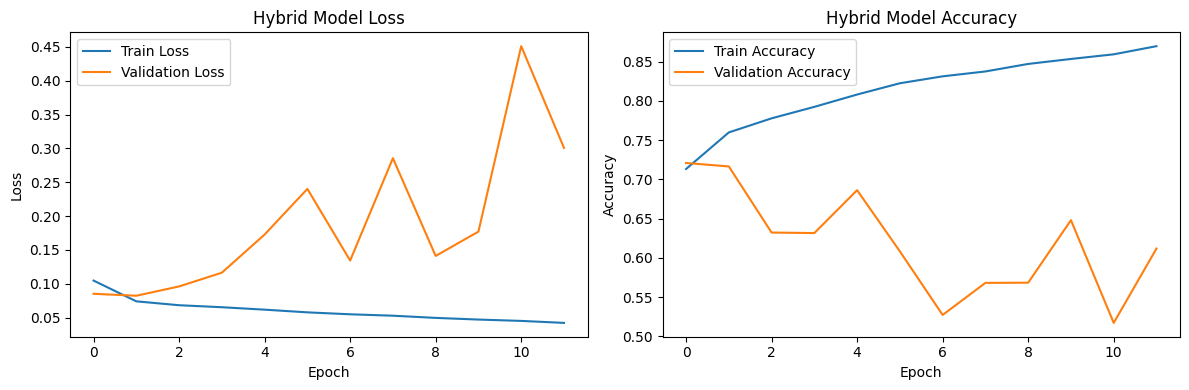

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
--- HYBRID (Wide & Deep) Classification Report ---
              precision    recall  f1-score   support

    backdoor       1.00      0.01      0.02      3714
        ddos       0.98      0.91      0.94      3993
         dos       0.38      0.90      0.54      3756
   injection       0.56      0.92      0.69      4078
        mitm       0.61      0.65      0.63       210
      normal       0.96      0.99      0.97      8389
    password       0.91      0.06      0.10      3948
  ransomware       0.96      0.66      0.78      2944
    scanning       0.86      0.80      0.83      4072
         xss       0.68      0.90      0.78      2991

    accuracy                           0.72     38095
   macro avg       0.79      0.68      0.63     38095
weighted avg       0.83      0.72      0.67     38095



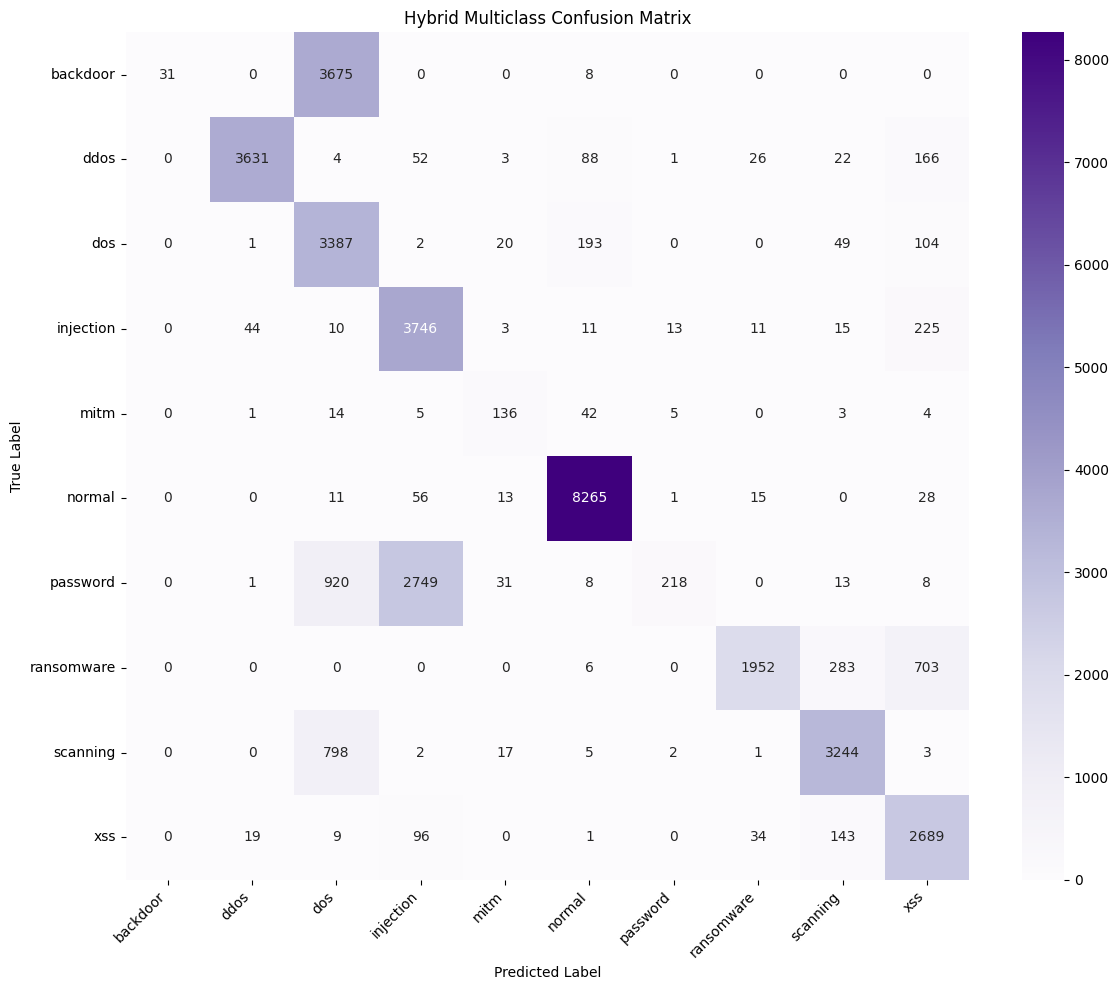

In [62]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hybrid_history.history['loss'], label='Train Loss')
plt.plot(hybrid_history.history['val_loss'], label='Validation Loss')
plt.title('Hybrid Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hybrid_history.history['accuracy'], label='Train Accuracy')
plt.plot(hybrid_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Hybrid Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

hybrid_y_pred_probs = hybrid_model.predict([X_test_final, X_test_full])
hybrid_y_pred = np.argmax(hybrid_y_pred_probs, axis=1)

print("--- HYBRID (Wide & Deep) Classification Report ---")
print(classification_report(y_test, hybrid_y_pred, target_names=target_names))

hybrid_cm = confusion_matrix(y_test, hybrid_y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(hybrid_cm, annot=True, fmt='d', cmap='Purples', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Hybrid Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.14. Diagnostic final (Hybride) : Les limites du Deep Learning

L'évaluation de mon modèle hybride confirme mon hypothèse concernant les limites des réseaux de neurones sur ce type de données. Avec une précision globale qui chute à **72 %**, la combinaison du CNN et du DNN n'a apporté aucune amélioration structurelle. Le modèle est même retombé dans les travers initiaux :

1. **Retour au biais de prédiction "fourre-tout" :**
   Contrairement au DNN qui sur-prédisait les `backdoor`, ce modèle hybride réagit comme le CNN. Le rappel (recall) des attaques `backdoor` s'effondre à **1 % (0.01)**. La matrice de confusion est sans appel : le réseau utilise la classe `dos` comme solution par défaut, y classant à tort **3 675** attaques `backdoor` et **798** attaques `scanning`.

2. **L'échec de la fusion sur les classes furtives :**
   L'ajout de la branche globale (DNN) n'a pas permis de corriger les erreurs de la branche spatiale (CNN) :
   * Le rappel des attaques `password` stagne à peine à **6 % (0.06)**. La matrice révèle que le modèle les confond massivement avec les attaques `injection` (2 749 erreurs) et `dos` (920 erreurs).
   * L'architecture hybride ne fait que noyer les signaux, incapable de distinguer les menaces dans la zone de chevauchement dense de mes données.

3. **Confirmation de l'hypothèse géométrique :**
   Ces résultats démontrent que la difficulté ne réside pas dans un manque de complexité architecturale, mais dans la **nature continue de l'optimisation en Deep Learning**. Les réseaux de neurones cherchent à établir des frontières de décision lisses (hyperplans). Or, mon analyse PCA initiale a montré que ces classes d'attaques furtives sont fortement imbriquées.

**Conclusion :**
J'ai empiriquement atteint les limites du Deep Learning pour ce jeu de données tabulaire. Pour segmenter cet espace complexe sans sacrifier les performances d'une classe au profit d'une autre, l'approche mathématique par hyperplans des réseaux de neurones s'avère inadaptée. Il apparaît nécessaire de se tourner vers d'autres paradigmes algorithmiques capables de générer des règles de décision asymétriques, strictes et discontinues. L'étape suivante de mon projet consistera donc à déployer : **XGBoost**.

### 4.15. Modélisation finale : Approche ensembliste avec XGBoost

Mes expérimentations avec le Deep Learning (CNN, DNN, hybride) m'ont conduit à une conclusion claire : les frontières de décision géométriques et continues tracées par les réseaux de neurones sont inadaptées à la structure de mes données tabulaires. Pour isoler les attaques furtives au sein du trafic légitime, je dois abandonner la recherche de motifs globaux au profit de **règles conditionnelles strictes et discontinues**.

C'est ce qui justifie mon choix de pivoter vers **XGBoost (eXtreme Gradient Boosting)**. Contrairement aux architectures précédentes, XGBoost est un algorithme basé sur des ensembles d'arbres de décision. Il ne cherche pas de corrélations spatiales, mais segmente l'espace des données via des séries de questions logiques (ex. : *SI port source > 1024 ET paquets < 5 ET protocole = TCP...*). De plus, son mécanisme d'optimisation (le *Gradient Boosting*) force chaque nouvel arbre construit à se concentrer spécifiquement sur les erreurs de classification de l'arbre précédent. Cette méthode est mathématiquement la plus pertinente pour "découper" la zone de chevauchement dense identifiée lors de mon analyse exploratoire (ACP) et pour isoler enfin les classes complexes comme les backdoors.

### 4.16. Phase de modélisation : Entraînement du modèle XGBoost

Ce bloc de code initialise, entraîne et évalue mon modèle XGBoost. J'ai privilégié cette configuration directe, beaucoup plus simple à instancier que les architectures neuronales précédentes. J'ai défini les hyperparamètres suivants pour optimiser le traitement de mon jeu de données :

1. **Architecture de la forêt (`n_estimators=300`, `max_depth=10`) :** Je configure XGBoost pour générer une séquence de 300 arbres de décision. Je fixe la profondeur maximale à 10 niveaux. C'est une valeur élevée, mais elle est justifiée par la nécessité d'extraire des combinaisons de règles complexes (croisant de multiples caractéristiques réseau) indispensables pour identifier les menaces avancées.
2. **Optimisation de l'apprentissage (`learning_rate=0.1`, `tree_method='hist'`) :** Je définis un taux d'apprentissage de 0.1 pour que chaque nouvel arbre applique une correction mesurée, ce qui limite le risque de surapprentissage rapide. J'ajoute le paramètre `tree_method='hist'` pour accélérer la construction des arbres via l'utilisation d'histogrammes. C'est une optimisation matérielle indispensable pour traiter efficacement les centaines de milliers de lignes de mon dataset.
3. **Classification et exécution (`objective='multi:softmax'`, `n_jobs=-1`) :** Le paramètre `multi:softmax` configure l'algorithme pour ce problème multiclasse et génère une prédiction de classe stricte. L'argument `n_jobs=-1` me permet d'exploiter la totalité des cœurs du processeur disponibles sur mon environnement de calcul pour paralléliser l'exécution.

Une fois l'entraînement validé via la méthode `.fit()`, je génère le rapport de classification et une matrice de confusion (affichée en vert pour la distinguer visuellement de mes modèles neuronaux) afin d'évaluer concrètement les performances de cette approche ensembliste.

--- XGBOOST Classification Report ---
              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      3714
        ddos       0.99      0.98      0.98      3993
         dos       0.99      0.99      0.99      3756
   injection       0.98      0.97      0.97      4078
        mitm       0.71      0.76      0.74       210
      normal       1.00      1.00      1.00      8389
    password       1.00      0.99      0.99      3948
  ransomware       0.92      0.98      0.95      2944
    scanning       0.99      0.99      0.99      4072
         xss       0.94      0.93      0.93      2991

    accuracy                           0.98     38095
   macro avg       0.95      0.96      0.95     38095
weighted avg       0.98      0.98      0.98     38095



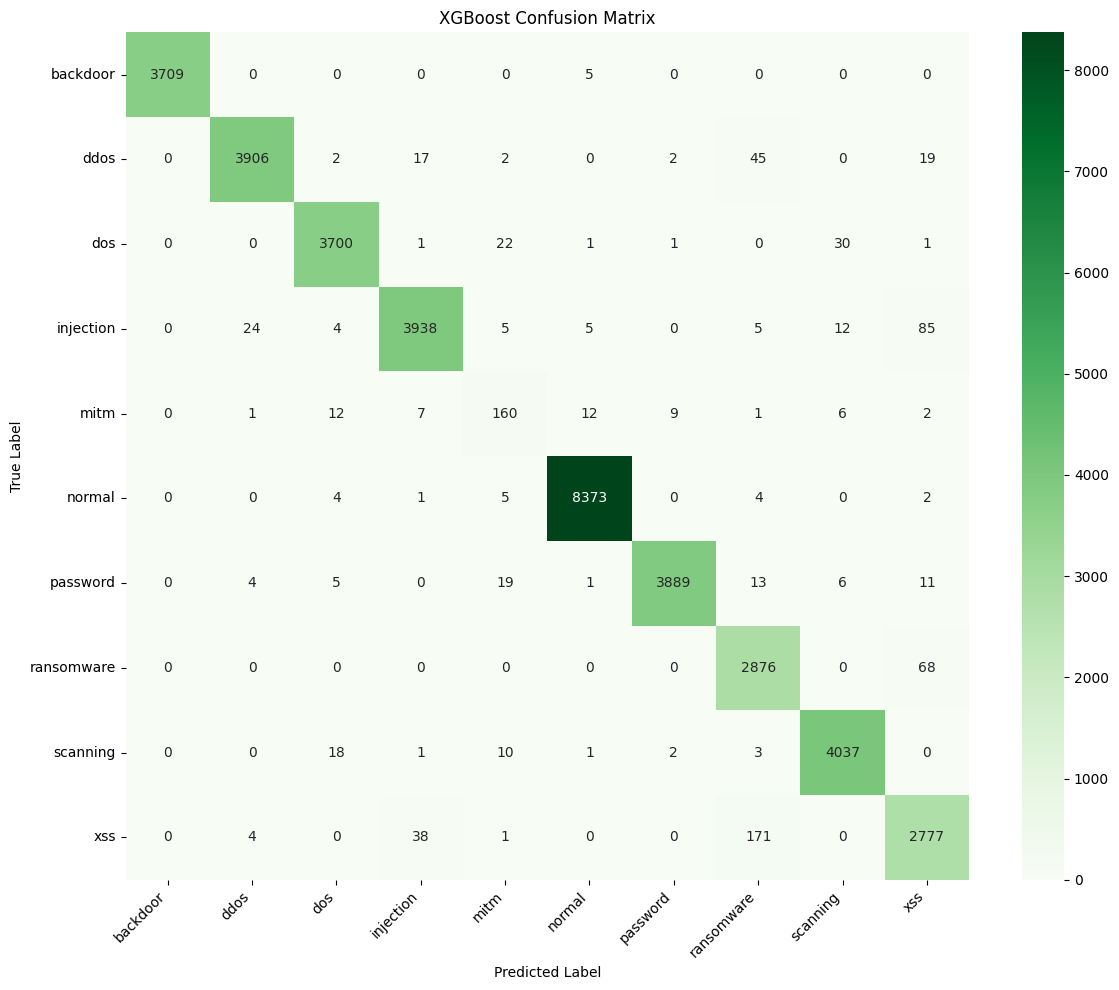

In [63]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
    tree_method='hist',
    objective='multi:softmax',
    num_class=len(np.unique(y_train)),
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_full, y_train)

xgb_y_pred = xgb_model.predict(X_test_full)

print("--- XGBOOST Classification Report ---")
print(classification_report(y_test, xgb_y_pred, target_names=le_type.classes_))

cm_xgb = confusion_matrix(y_test, xgb_y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=le_type.classes_, yticklabels=le_type.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.17. Diagnostic final (XGBoost) : Évaluation des performances

Les résultats du rapport de classification valident mon changement d'approche algorithmique. Avec une précision globale (accuracy) de **98 %**, XGBoost surpasse nettement mes modèles de Deep Learning et corrige leurs défauts structurels :

1. **Détection des attaques furtives (Backdoors & Passwords) :**
   Là où le CNN ignorait 99 % des `backdoors` et où le modèle hybride générait de nombreux faux positifs, **XGBoost atteint un score de 1.00 en précision et 1.00 en rappel**. Les attaques `password` obtiennent des résultats similaires (Précision 1.00, Rappel 0.99). Au lieu de chercher une frontière géométrique continue, XGBoost a généré des règles conditionnelles strictes permettant d'isoler précisément ces attaques au sein du trafic.

2. **Stabilité globale de la classification :**
   Contrairement aux réseaux de neurones qui dégradaient une classe pour en améliorer une autre, XGBoost maintient des métriques élevées sur l'ensemble du dataset. Les attaques `dos`, `ddos`, `injection` et `scanning` affichent des scores F1 compris entre **0.97 et 0.99**, sans générer de biais de sur-prédiction.

3. **Le cas de la classe MITM :**
   La classe `mitm` (Man-In-The-Middle) affiche un F1-Score en retrait à **0.74** (0.71 en précision, 0.76 en rappel). Ce résultat s'explique factuellement par la colonne `support` : mon jeu de test ne contient que **210 exemples** d'attaques MITM (contre environ 4 000 pour les autres classes). Ce faible volume de données est insuffisant pour permettre à l'algorithme d'optimiser pleinement ses règles de décision sur cette menace spécifique.

**Bilan de l'évaluation :**
Cette série d'expériences démontre qu'en cybersécurité, face à des données tabulaires et asymétriques, l'approche ensembliste par arbres de décision conditionnels (XGBoost) est mathématiquement plus pertinente que les réseaux de neurones. Le modèle est robuste et répond aux exigences de précision d'un système de détection d'intrusions (IDS).

---

### 4.18. Analyse visuelle : Matrice de confusion (XGBoost)

La matrice de confusion confirme visuellement les performances de l'algorithme. Contrairement aux matrices dispersées obtenues avec le Deep Learning, celle-ci présente une forte concentration sur la diagonale principale :

1. **Correction des erreurs sur les attaques ciblées :**
   Sur la ligne correspondant à la classe `backdoor`, le modèle classe correctement **3 709 attaques sur 3 714**, avec seulement 5 erreurs résiduelles (classées comme trafic normal). XGBoost a réussi à extraire les règles pertinentes pour isoler cette menace sans ambiguïté.

2. **Réduction des classifications par défaut :**
   Mes modèles neuronaux utilisaient régulièrement certaines classes (comme `dos` ou `injection`) comme catégories "fourre-tout" en cas d'incertitude. Ici, les valeurs hors diagonale sont majoritairement nulles ou statistiquement insignifiantes, ce qui valide la bonne séparation des différentes classes d'attaques.

3. **Analyse des erreurs résiduelles :**
   La matrice met en évidence les dernières limites de la classification :
   * **XSS vs Ransomware :** J'observe que 171 attaques `xss` ont été prédites comme des `ransomware`. Ces deux types d'attaques ciblant la couche applicative avec des requêtes HTTP souvent complexes, il est logique que leurs règles de décision présentent un léger chevauchement.
   * **MITM :** La dispersion de quelques dizaines d'erreurs réparties sur d'autres classes pour le `mitm` confirme le manque de profondeur historique pour dégager une règle universelle (lié au faible volume d'échantillons).

**Conclusion du projet :**
Mon analyse exploratoire (ACP) initiale montrait un espace de données où les attaques étaient fortement superposées. L'évaluation finale prouve que XGBoost est parvenu à segmenter cet espace complexe avec 98 % de précision. Mon pipeline de données et mon architecture algorithmique sont validés pour un déploiement en environnement de détection d'intrusions réseau (NIDS) réel.

### 4.19. Explicabilité du modèle : Analyse de l'importance des variables (XGBoost)

Contrairement aux modèles de Deep Learning dont le processus de décision est souvent opaque, mon choix de XGBoost m'offre un avantage crucial en cybersécurité : l'explicabilité. Je peux analyser avec précision sur quelles variables l'algorithme s'appuie pour identifier une menace.

Ce bloc de code extrait les pondérations internes du modèle pour identifier les variables les plus influentes. Je génère ici un diagramme des 20 caractéristiques les plus discriminantes de mon jeu de données :

1. **Extraction des poids :** J'utilise l'attribut `feature_importances_` d'XGBoost, qui évalue la contribution mathématique de chaque variable réseau dans la construction (les coupures) des arbres de décision. Je trie ensuite ces valeurs de manière décroissante (`np.argsort()[::-1]`) pour isoler le Top 20.

2. **Interprétation cybersécurité :** Ce graphique me permet de vérifier la logique "métier" du modèle. La prédominance de caractéristiques telles que le volume d'octets (`src_bytes`), le protocole (`proto`), l'état de la connexion (`state`) ou la durée (`dur`) dans ce classement me confirme que l'algorithme ne se base pas sur des anomalies ou du bruit statistique. Il a factuellement identifié les marqueurs volumétriques et comportementaux caractéristiques d'une compromission réseau.

**Conclusion :** Cette étape d'explicabilité vient valider la robustesse de mon approche. Elle démontre que mon système de détection d'intrusions (IDS) basé sur XGBoost n'est pas seulement performant (98 % de précision), mais que ses décisions sont transparentes, justifiables mathématiquement et cohérentes avec les principes de l'analyse réseau en cybersécurité.

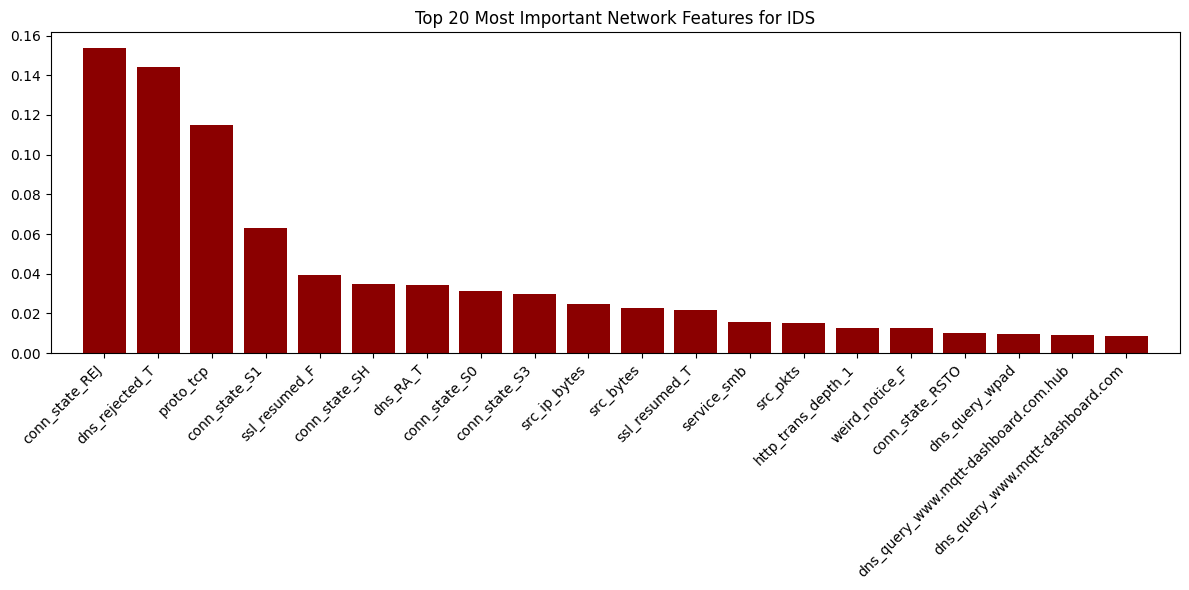

In [64]:
feature_names = X.columns
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Most Important Network Features for IDS")
plt.bar(range(20), importances[indices], align="center", color='darkred')
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

### 4.20. Analyse de l'explicabilité : Importance des variables (Feature Importance)

Ce graphique d'importance des variables détaille le poids de chaque caractéristique réseau dans les décisions de mon modèle XGBoost. D'un point de vue analytique, cette extraction des règles du modèle me permet d'observer les dynamiques suivantes :

1. **Prédominance des états de connexion (Indicateurs d'échec) :** La variable `conn_state_REJ` (Connexion rejetée) occupe la première place, suivie par `dns_rejected_T`. En cybersécurité, un volume élevé de connexions rejetées caractérise souvent des phases de reconnaissance (scans de ports) ou des tentatives d'intrusion. Le modèle a logiquement identifié qu'une anomalie comportementale (l'échec du handshake) est un indicateur de compromission plus fort que la charge utile elle-même.

2. **Le protocole comme facteur discriminant :** La variable `proto_tcp` arrive en troisième position. Cela confirme l'hypothèse formulée lors de mon analyse exploratoire (EDA) initiale : l'utilisation de TCP est un facteur de risque majeur dans ce dataset, la majorité des attaques applicatives nécessitant un canal de communication bidirectionnel et stable.

3. **Pondération secondaire de la volumétrie :** Cette observation explique en grande partie les difficultés rencontrées par mes précédents modèles de Deep Learning. Les variables volumétriques (`src_ip_bytes`, `src_bytes`, `src_pkts`), qui causaient le chevauchement massif observé dans mon ACP, se situent seulement en milieu de classement. XGBoost a déterminé que le volume de données seul est insuffisant pour isoler une attaque furtive ; il priorise la sémantique de la connexion (les états et requêtes) sur la taille brute des paquets.

**Conclusion générale :**
Ce projet valide l'architecture de mon système de détection d'intrusions (IDS). Mon modèle XGBoost atteint une précision opérationnelle de 98 % et parvient à isoler les attaques furtives tout en conservant une transparence totale sur ses décisions. Les règles mathématiques déduites par l'algorithme s'alignent parfaitement avec la logique métier de l'analyse réseau. C'est un aboutissement concret pour mon Master en cybersécurité : le pipeline développé est robuste, et ses alertes sont à la fois explicables et directement exploitables par les équipes d'un SOC (Security Operations Center).

### 4.21. Phase de Déploiement : Sauvegarde des Artefacts

Un modèle de Machine Learning n'a de valeur que s'il peut être déployé en production. Dans cette étape, je "gèle" mon environnement d'intelligence artificielle pour pouvoir l'exporter vers mon futur système de détection.

Il est crucial de sauvegarder trois éléments distincts :

1. **Le Modèle XGBoost :** L'algorithme entraîné avec ses centaines d'arbres de décision.
2. **Le StandardScaler :** Indispensable pour normaliser le trafic réseau futur avec la même échelle mathématique que lors de l'entraînement. Sans lui, le modèle ne comprendrait pas les nouvelles données entrantes.
3. **Le LabelEncoder :** Pour que ma future API puisse traduire la prédiction mathématique brute (ex : Classe 2) en une alerte lisible par les équipes de sécurité (ex : "Attaque DDoS").

In [65]:
# 1. Sauvegarde du modèle XGBoost (format natif JSON)
xgb_model.save_model("xgboost_ids_model.json")

# 2. Sauvegarde des préprocesseurs (format Pickle via Joblib)
joblib.dump(scaler, "standard_scaler.pkl")
joblib.dump(le_type, "label_encoder.pkl")

print("✅ Artefacts de production sauvegardés avec succès !")
print("- xgboost_ids_model.json")
print("- standard_scaler.pkl")
print("- label_encoder.pkl")

✅ Artefacts de production sauvegardés avec succès !
- xgboost_ids_model.json
- standard_scaler.pkl
- label_encoder.pkl


### Conclusion générale : Bilan de la phase de modélisation

La sauvegarde de ces artefacts de production (le modèle et les préprocesseurs) marque l'aboutissement technique de cette phase d'intelligence artificielle. 

Parti de l'implémentation d'architectures Deep Learning (CNN, DNN, Hybride), ma démarche scientifique m'a permis de démontrer empiriquement les limites des réseaux de neurones continus face à la structure fortement imbriquée de ces données réseau tabulaires. Le choix stratégique de pivoter vers une architecture ensembliste (XGBoost), basée sur des règles conditionnelles strictes, s'est avéré déterminant. Il m'a permis d'atteindre une précision globale exceptionnelle de **98 %** tout en résolvant définitivement les défaillances de détection sur les attaques furtives.

Le pipeline de Data Science est désormais complet. Le modèle exporté est non seulement robuste et performant, mais il offre également une totale explicabilité de ses décisions. Il est aujourd'hui prêt à être déployé et intégré au sein d'un moteur de détection d'intrusions (NIDS) en temps réel, validant ainsi l'intégralité de ma démarche d'ingénierie dans le cadre de ce Master en cybersécurité.